# Upwelling Indices Comparison

In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.floating_axes as FA
import mpl_toolkits.axisartist.grid_finder as GF

In [2]:
# mask
def coastal_band_mask(ds, var='u10', iterations=10):
    """
    Create a coastal band mask by dilating the coastline edge.

    Parameters
    ----------
    ds : xr.Dataset
        Must contain 2D lat/lon coords and the target variable.
    var : str
        Variable name used to detect land (NaN) vs ocean.
    iterations : int
        Number of dilation steps (~10 km per iteration on a ~10 km grid).

    Returns
    -------
    da_mask : xr.DataArray
        Boolean mask (True inside the coastal band).
    """
    valid2d = np.isfinite(ds[var].mean(dim='time')).values.astype(bool)

    eroded = binary_erosion(valid2d, structure=np.ones((3, 3)), iterations=1)
    coast = valid2d & (~eroded)

    band = binary_dilation(coast, structure=np.ones((3, 3)), iterations=iterations) & valid2d

    da_mask = xr.DataArray(
        band,
        dims=('lat', 'lon'),
        coords={'lat': ds['lat'], 'lon': ds['lon']},
    )
    return da_mask

In [3]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

In [4]:
AV = xr.open_dataset('AV.nc').AV.compute()

In [5]:
Pumping = xr.open_dataset('AV.nc').Epumping.compute()
Pumping

<xarray.DataArray 'Epumping' (time: 432, lat: 134, lon: 194)> Size: 90MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87

In [6]:
Ek_t = xr.open_dataset('Winds_components_Lu.nc').etransport.isel(offshore=0)
Ek_t = (Ek_t.swap_dims({'coast_point': 'lat'})
         .drop_vars(['coast_point', 'lon', 'bearing', 'distance', 'f', 'offshore'])
         .rename('Ek_t'))
Ek_t

<xarray.DataArray 'Ek_t' (time: 432, lat: 134)> Size: 463kB
[57888 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Attributes:
    units:      m/s
    long_name:  Ekman transport (normalized by distance)

In [7]:
CUTI = xr.open_dataset('CUTI_BEUTI_components.nc').CUTI.compute()
BEUTI = xr.open_dataset('CUTI_BEUTI_components.nc').BEUTI.compute()
ugeo = xr.open_dataset('CUTI_BEUTI_components.nc').u_geo.compute()
UGEO = xr.open_dataset('CUTI_BEUTI_components.nc').UGEO.compute()
CROCO_j = xr.open_dataset('CUTI_BEUTI_components.nc').CROCO_j.compute()

In [8]:
CUI = xr.open_dataset('CUI.nc').compute()
CUI

<xarray.Dataset> Size: 236kB
Dimensions:  (time: 432, lat: 134)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    CUI_cc   (time, lat) float32 232kB 1.252 1.419 1.36 ... 1.755 1.777 1.826

In [9]:
u = xr.open_dataset('UV_velocities.nc').compute().transpose('time','lat','lon')
u = u.where(u!=0,np.nan)
mask = coastal_band_mask(u,'u',10).sel(lon=slice(-85,None),lat=slice(-16,-5))
u = u.where(mask).u
u

<xarray.DataArray 'u' (time: 432, lat: 134, lon: 194)> Size: 90MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
Attributes:
    long_name:      averaged u-momentum component
    units:          meter second-1
    field:          u-velocity, scalar, series
    standard_name:  sea_water_x_velocity_at_u_location

In [10]:
#Chlorphyll
CHL = xr.open_dataset('../../../NHCS/hincast_1980-2015/Chlorophyll_CROCO.nc').drop_vars('s_rho').compute()
CHL = CHL.where(mask).sel(lon=slice(-85,None),lat=slice(-16,-5))
CHL

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 432, lat: 134, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    chla     (time, lat, lon) float64 90MB nan nan nan nan ... nan nan nan nan

In [11]:
## CROCO
wmld = xr.open_dataset('W_mld_Croco.nc').compute()
mask = coastal_band_mask(wmld, var='WMLD', iterations=10)
wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(-16,-5))
wmld

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 432, lat: 134, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    WMLD     (time, lat, lon) float64 90MB nan nan nan nan ... nan nan nan nan

## Latitudinal Structure

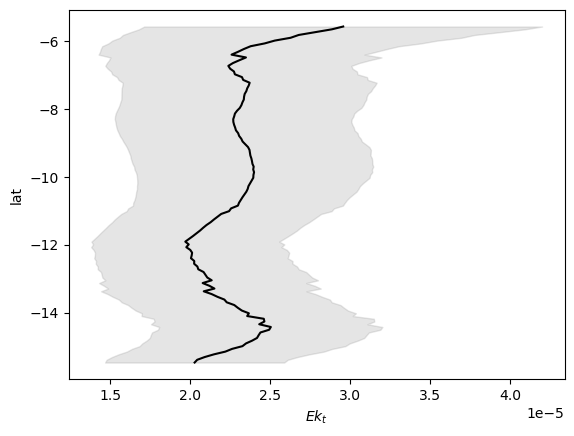

In [12]:
std = Ek_t.std(dim='time').rolling(lat=13, center=True).mean().rename('$Ek_t$')
mean = Ek_t.mean('time').rolling(lat=13,center=True).mean().rename('$Ek_t$')

Ek_t.mean('time').rolling(lat=13,center=True).mean().rename('$Ek_t$').plot(y='lat',color='black', linewidth=1.5)
plt.fill_betweenx(mean.lat,
                        mean - std,
                        mean + std,
                        color='gray',
                        alpha=0.2,
                        label='±1 SD')
    

In [13]:
d = (1/12)*10*111*1000

data_dict = {
    "WMLD": wmld.WMLD.mean("lon"),
    "AV": AV.mean(dim=('lon')).rename('AV [m/s]'),
    "EkT": Ek_t.rename('Ek_t [m/s]'),
    "CUI": CUI.CUI_cc.rename('$C^{\circ}$'),
    "CUTI": (CUTI/d).mean(dim=('lon')).rename({'lat_band': 'lat'}).rename('CUTI [$m^{2}\cdot s^{-1}$]'),
    "BEUTI": BEUTI.mean(dim=('lon')).rename({'lat_band': 'lat'}).rename('$BEUTI [mmol N \cdot m^{-1} \cdot s^{-1}]$'),
    # "UGEO": (UGEO/d).mean(dim=('lon')).rename({'lat_band': 'lat'}).rename('UGEO [m2/s]'),
}


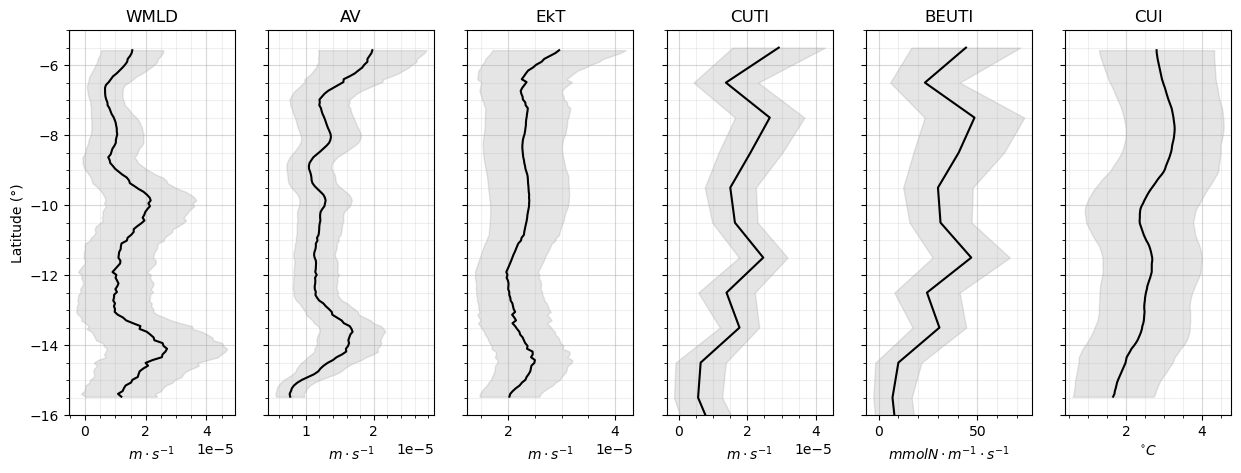

In [14]:
# indx = ['WMLD', 'AV', 'EkT', 'CUTI','CUI', 'BEUTI','UGEO']
# units = ['m', 'm/s', 'm/s', 'm2/s', 'C', '$mmol N \cdot m^{-1} \cdot s^{-1}$', 'm2/s']
from matplotlib.ticker import AutoMinorLocator

indx = ['WMLD', 'AV', 'EkT', 'CUTI', 'BEUTI','CUI']
units = ['$m \cdot s^{-1}$', '$m \cdot s^{-1}$', '$m \cdot s^{-1}$', '$m \cdot s^{-1}$', '$mmol N \cdot m^{-1} \cdot s^{-1}$', '$^{\circ}C$']

n_indices = len(indx)

# ncols = int(np.ceil(len(indx) / 3))
fig, axes = plt.subplots(1, 6, figsize=(15, 5))

axes = np.array(axes).flatten()

lat = AV.lat.values

for i, key in enumerate(indx):

    ax = axes[i]

    da = data_dict[key]   # we'll define this below
    
    if da.lat.size > 12:
        # --- FULL LAT GRID ---
        mean = da.mean("time").rolling(lat=13, center=True).mean()
        std  = da.std("time").rolling(lat=13, center=True).mean()
        # mean = da.mean("time")
        # std  = da.std("time")
        lat  = da.lat
    
        ax.plot(mean, lat, color="black")
        ax.fill_betweenx(lat, mean-std, mean+std, alpha=0.2,color='gray')

    else:
        # --- COASTAL POINTS (12 points) ---
        mean = da.mean("time")
        std  = da.std("time")
        lat  = da.lat

        ax.plot(mean, lat, color="black")
        ax.fill_betweenx(lat, mean-std, mean+std, alpha=0.2,color='gray')

    ax.set_title(key)
    ax.set_xlabel(units[i])
    ax.set_ylim([-16, -5])
    ax.grid(which='major', alpha=0.5)
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(which='minor', alpha=0.2)

    # Keep y-axis only for first subplot
    if i == 0:
        ax.set_ylabel("Latitude (°)")
    else:
        ax.set_yticklabels([])   # removes labels

## Seasonality

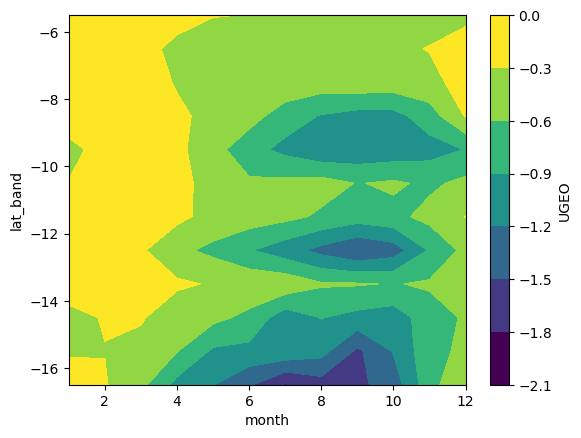

In [15]:
# seasonality(u).mean(dim=('lon')).plot.contourf(x='month')
seasonality(UGEO).mean(dim=('lon')).plot.contourf(x='month')

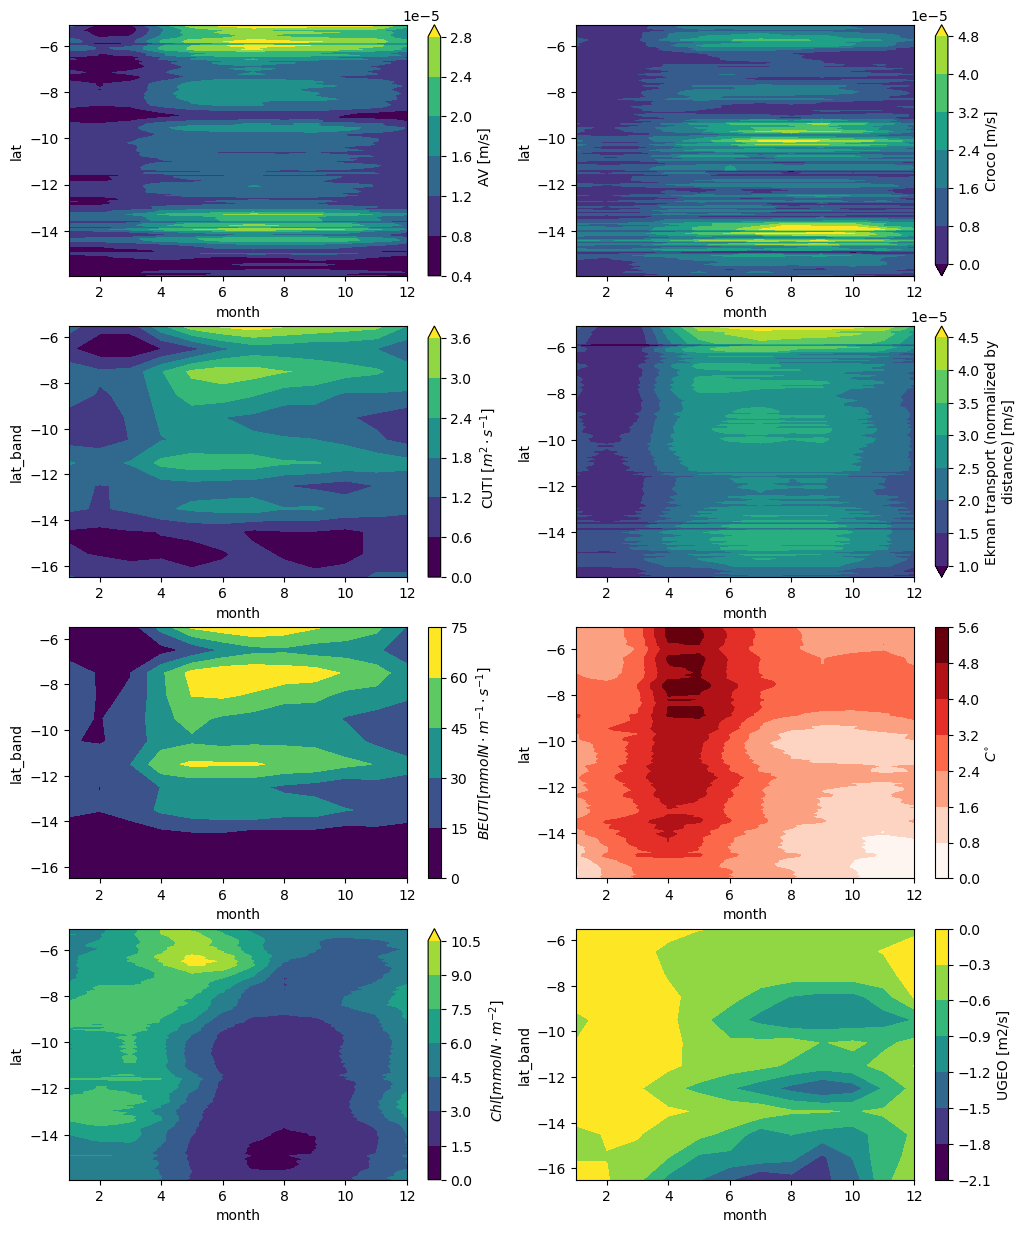

In [16]:
fig,ax = plt.subplots(4,2,figsize=(12,15))
seasonality(AV).mean('lon').rename('AV [m/s]').plot.contourf(x='month',robust=True,ax=ax[0,0])
seasonality(wmld).WMLD.mean('lon').rename('Croco [m/s]').plot.contourf(x='month',robust=True,ax=ax[0,1])
seasonality(CUTI).mean('lon').rename('CUTI [$m^{2}\cdot s^{-1}$]').plot.contourf(robust=True,ax=ax[1,0])
seasonality(Ek_t).rename('Ek_t [m/s]').plot.contourf(x='month',robust=True,ax=ax[1,1])
seasonality(BEUTI).mean('lon').rename('$BEUTI [mmol N \cdot m^{-1} \cdot s^{-1}]$').plot.contourf(robust=True,ax=ax[2,0])
seasonality(CUI.CUI_cc).rename('$C^{\circ}$').plot.contourf(x='month',robust=True,ax=ax[2,1],cmap='Reds')
seasonality(CHL.chla).rename('$Chl [mmol N \cdot m^{-2}]$').mean('lon').plot.contourf(x='month',robust=True,ax=ax[3,0])
seasonality(UGEO).mean(dim=('lon')).rename('UGEO [m2/s]').plot.contourf(x='month')

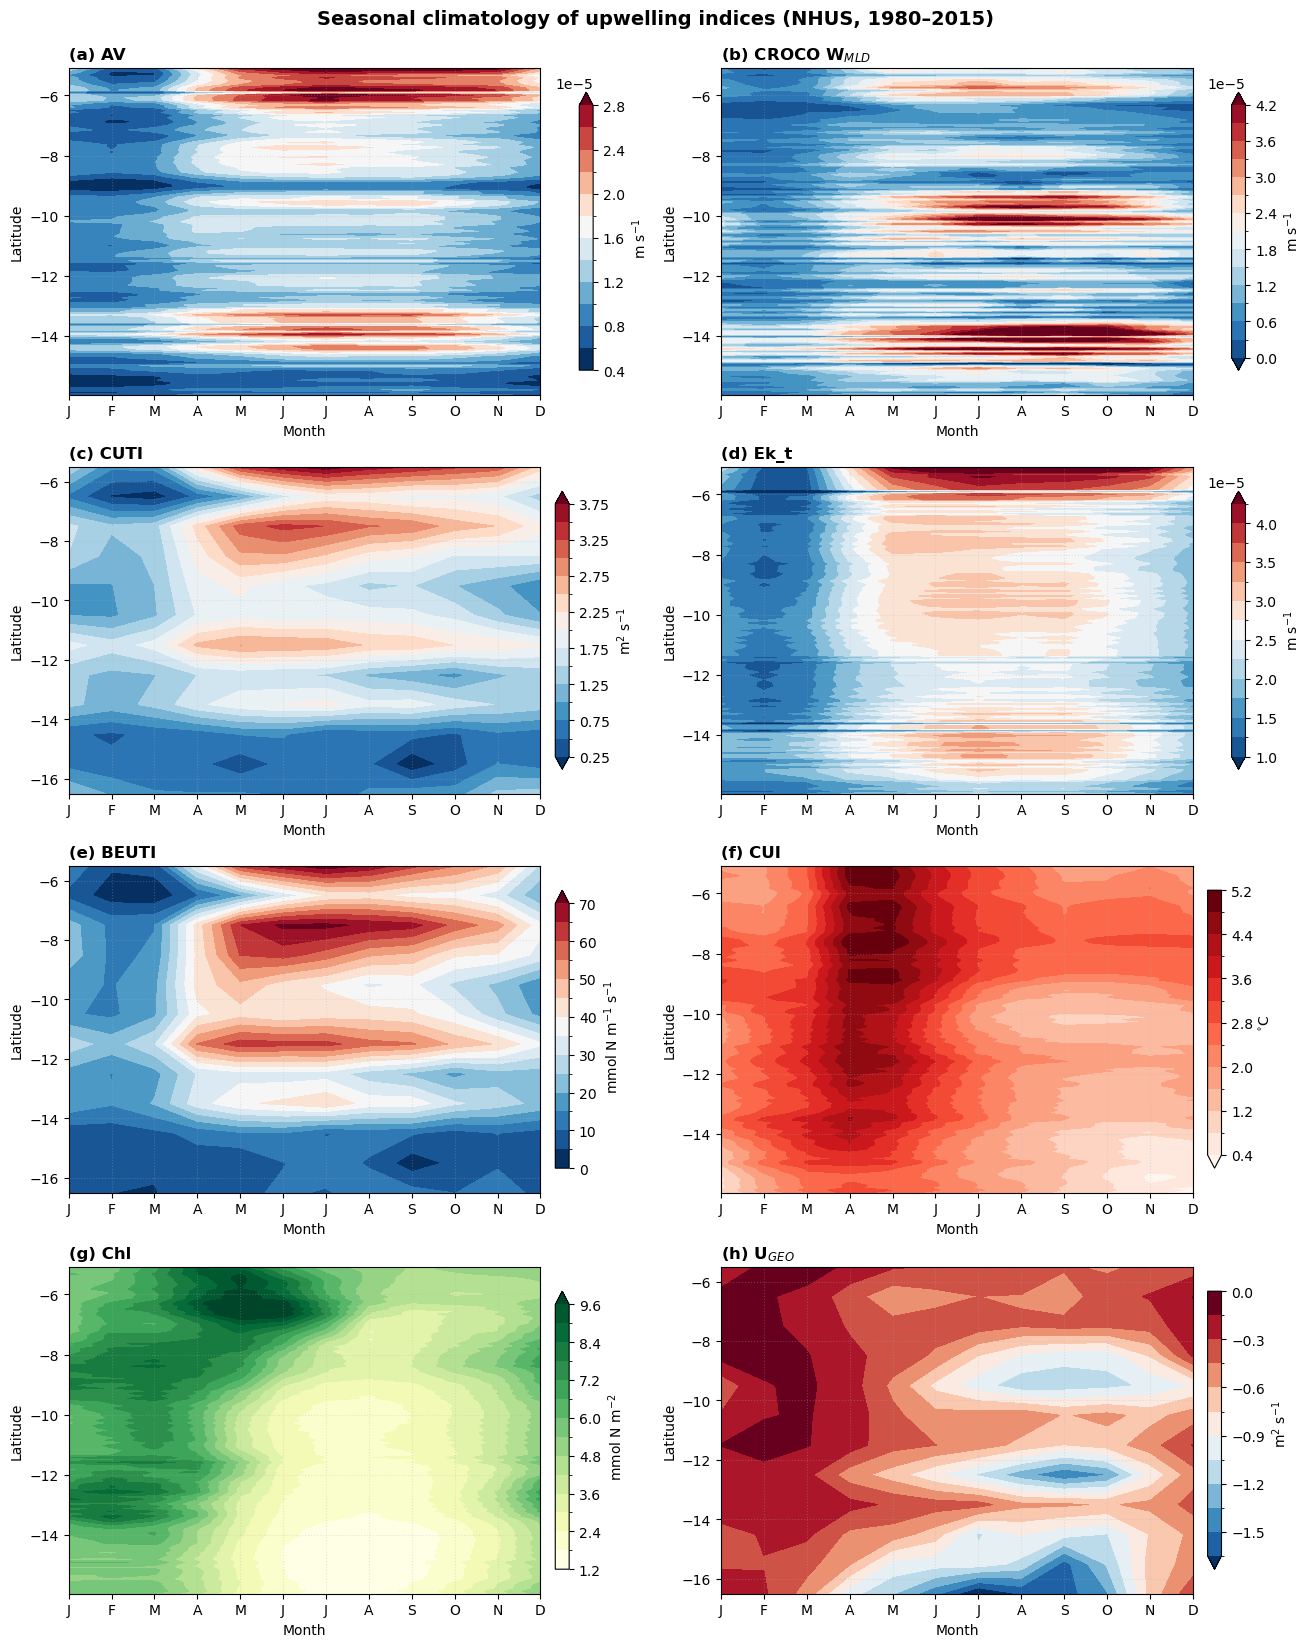

In [17]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

fig, ax = plt.subplots(4, 2, figsize=(13, 16), constrained_layout=True)

panels = [
    (ax[0,0], seasonality(AV).mean('lon'),                'AV',    'm s$^{-1}$',                          'RdBu_r', None),
    (ax[0,1], seasonality(wmld).WMLD.mean('lon'),         'CROCO W$_{MLD}$', 'm s$^{-1}$',                 'RdBu_r', None),
    (ax[1,0], seasonality(CUTI).mean('lon'),              'CUTI',  'm$^{2}$ s$^{-1}$',                    'RdBu_r', None),
    (ax[1,1], seasonality(Ek_t),                            'Ek_t',   'm s$^{-1}$',                          'RdBu_r', None),
    (ax[2,0], seasonality(BEUTI).mean('lon'),             'BEUTI', 'mmol N m$^{-1}$ s$^{-1}$',            'RdBu_r', None),
    (ax[2,1], seasonality(CUI.CUI_cc),                     'CUI',   '$^{\circ}$C',                         'Reds',   None),
    (ax[3,0], seasonality(CHL.chla).mean('lon'),          'Chl',   'mmol N m$^{-2}$',                     'YlGn',   None),
    (ax[3,1], seasonality(UGEO).mean('lon'),              'U$_{GEO}$', 'm$^{2}$ s$^{-1}$',                'RdBu_r', None),
]

panel_labels = list('abcdefgh')

for (a, da, title, units, cmap, _), label in zip(panels, panel_labels):
    p = da.plot.contourf(
        x='month',
        ax=a,
        robust=True,
        cmap=cmap,
        levels=15,
        add_colorbar=True,
        cbar_kwargs={'label': units, 'shrink': 0.85, 'pad': 0.02},
    )
    a.set_title(f'({label}) {title}', loc='left', fontsize=12, fontweight='bold')
    a.set_xlabel('Month')
    a.set_ylabel('Latitude')
    a.set_xticks(range(1, 13))
    a.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    a.grid(alpha=0.3, linestyle=':')

fig.suptitle('Seasonal climatology of upwelling indices (NHUS, 1980–2015)',
             fontsize=14, fontweight='bold', y=1.02)

# --- Save to PDF ---
# with PdfPages('upwelling_indices_seasonality.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()

### Seasonality paper plot

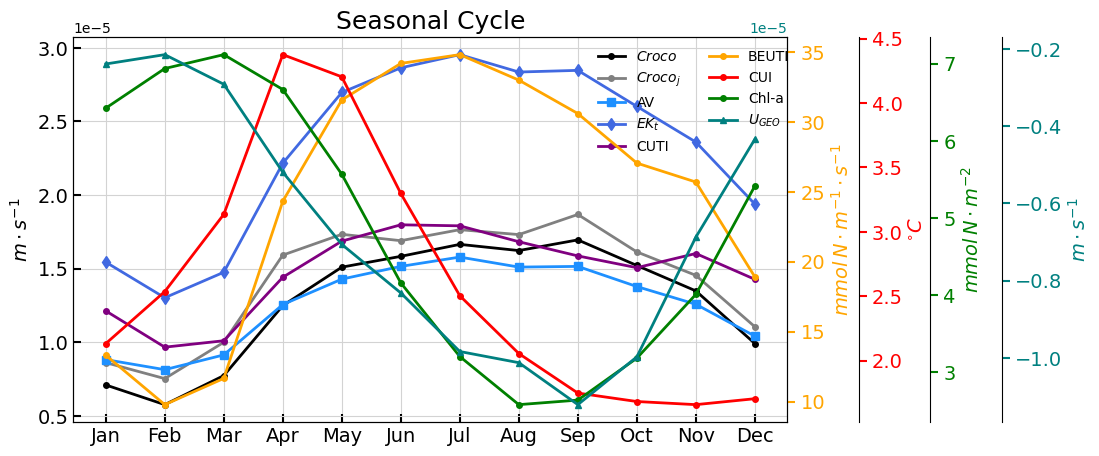

In [18]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.backends.backend_pdf import PdfPages

d = (1/12)*10*111*1000

def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

# ============================================================
# Compute seasonal cycles (scalar time series, one value per month)
# ============================================================
wmlds  = seasonality(wmld.WMLD).mean(dim=('lat', 'lon'))
Croco_j = seasonality(CROCO_j).mean(dim=('lon','lat_band'))
AVs    = seasonality(AV).mean(dim=('lat', 'lon'))
Ek_ts   = seasonality(Ek_t).mean(dim='lat')
CUTIs  = seasonality(CUTI).mean(dim=('lat_band', 'lon'))/d
BEUTIs = seasonality(BEUTI).mean(dim=('lat_band', 'lon'))
CUIs   = seasonality(CUI.CUI_cc).mean(dim='lat')
CHLs   = seasonality(CHL.chla).mean(dim=('lat', 'lon'))
UGEOs  = seasonality(UGEO).mean(dim=('lat_band', 'lon'))/d

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# ============================================================
# Plot
# ============================================================
fig, host = plt.subplots(figsize=(12, 5))

par1 = host.twinx()
par2 = host.twinx()
par3 = host.twinx()
par4 = host.twinx()

par2.spines["right"].set_position(("axes", 1.1))
par3.spines["right"].set_position(("axes", 1.2))
par4.spines["right"].set_position(("axes", 1.3))

make_patch_spines_invisible(par2)
make_patch_spines_invisible(par3)
make_patch_spines_invisible(par4)

par2.spines["right"].set_visible(True)
par3.spines["right"].set_visible(True)
par4.spines["right"].set_visible(True)

# --- Lines on host (transport / velocity axis) ---
W,    = host.plot(wmlds.month,  wmlds,  linewidth=2, marker='o', markersize=4, color='black',     label='$Croco$')
Cj = host.plot(Croco_j.month,  Croco_j,  linewidth=2, marker='o', markersize=4, color='gray',     label='$Croco_{j}$')
AVi,  = host.plot(AVs.month,    AVs,    linewidth=2, marker='s', markersize=6, color='dodgerblue', label='AV')
BUi,  = host.plot(Ek_ts.month,   Ek_ts,   linewidth=2, marker='d', markersize=6, color='royalblue',  label='$EK_{t}$')
CUTi, = host.plot(CUTIs.month,  CUTIs,  linewidth=2, marker='o', markersize=4, color='purple',     label='CUTI')


# --- Secondary axes ---
BEUTi, = par1.plot(BEUTIs.month, BEUTIs, linewidth=2, marker='o', markersize=4, color='orange', label='BEUTI')
CUi,   = par2.plot(CUIs.month,   CUIs,   linewidth=2, marker='o', markersize=4, color='red',    label='CUI')
Chli,  = par3.plot(CHLs.month,   CHLs,   linewidth=2, marker='o', markersize=4, color='green',  label='Chl-a')
UGi,  = par4.plot(UGEOs.month,  UGEOs,  linewidth=2, marker='^', markersize=5, color='teal',       label='$U_{GEO}$')

# --- Labels ---
host.set_ylabel('$m \cdot s^{-1}$',               fontsize=14)
par1.set_ylabel('$mmol\,N \cdot m^{-1} \cdot s^{-1}$', fontsize=14)
par2.set_ylabel('$^{\circ}C$',                         fontsize=14)
par3.set_ylabel('$mmol\,N \cdot m^{-2}$',              fontsize=14)
par4.set_ylabel('$m \cdot s^{-1}$',              fontsize=14)

host.yaxis.label.set_color('black')
par1.yaxis.label.set_color('orange')
par2.yaxis.label.set_color('red')
par3.yaxis.label.set_color('green')
par4.yaxis.label.set_color('teal')

# --- Ticks ---
tkw = dict(size=6, width=1.5)
host.tick_params(axis='y', colors='black',  **tkw, labelsize=14)
par1.tick_params(axis='y', colors='orange', **tkw, labelsize=14)
par2.tick_params(axis='y', colors='red',    **tkw, labelsize=14)
par3.tick_params(axis='y', colors='green',  **tkw, labelsize=14)
par4.tick_params(axis='y', colors='teal',  **tkw, labelsize=14)

host.tick_params(direction='in', **tkw)

host.set_xticks(range(1, 13))
host.set_xticklabels(months, fontsize=14)

# --- Legend ---
handles, labels = [], []
for ax_ in (host, par1, par2, par3,par4):
    h, l = ax_.get_legend_handles_labels()
    handles += h
    labels  += l

fig.subplots_adjust(right=0.72)
host.legend(
    handles, labels,
    fontsize=10, ncol=2,
    frameon=False,
    loc='upper right',
    bbox_to_anchor=(1.02, 1.0),
)

host.grid(True, color='lightgrey', zorder=0)
host.set_axisbelow(True)
plt.title('Seasonal Cycle', fontsize=18)

# # # --- Save ---
# with PdfPages('figures/Seasonal_cycle.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()

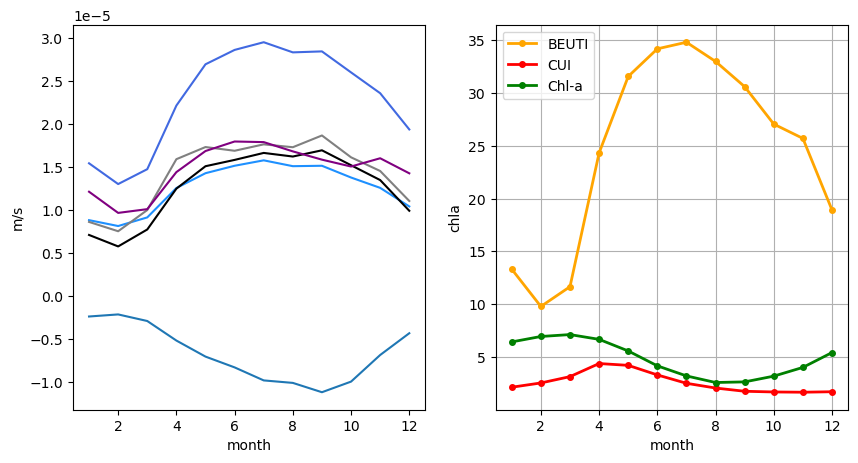

In [19]:
d = (1/12)*10*111*1000

fig,ax = plt.subplots(1,2,figsize=(10,5))


seasonality(AV).mean(dim=('lon','lat')).plot(label='AV',color='dodgerblue',ax=ax[0])
seasonality(wmld).WMLD.mean(dim=('lon','lat')).plot(label='CROCO',color='Black',ax=ax[0])
seasonality(CROCO_j).mean(dim=('lon','lat_band')).plot(label='CROCO-j',color='gray',ax=ax[0])
seasonality(CUTI/d).mean(dim=('lon','lat_band')).plot(label='CUTI',color='purple',ax=ax[0])
seasonality(UGEO/d).mean(dim=('lon','lat_band')).plot(label='Ugeo',ax=ax[0])
seasonality(Ek_t).mean('lat').rename('m/s').plot(label='$EK_t$',color='royalblue',ax=ax[0])

seasonality(BEUTI).mean(dim=('lat_band', 'lon')).plot(linewidth=2, marker='o', markersize=4, color='orange', label='BEUTI',ax=ax[1])
seasonality(CUI.CUI_cc).mean(dim='lat').plot(linewidth=2, marker='o', markersize=4, color='red',    label='CUI',ax=ax[1])
seasonality(CHL.chla).mean(dim=('lat', 'lon')).plot(linewidth=2, marker='o', markersize=4, color='green',  label='Chl-a',ax=ax[1])



plt.legend()
plt.grid(True)
# plt.title('Wind based')

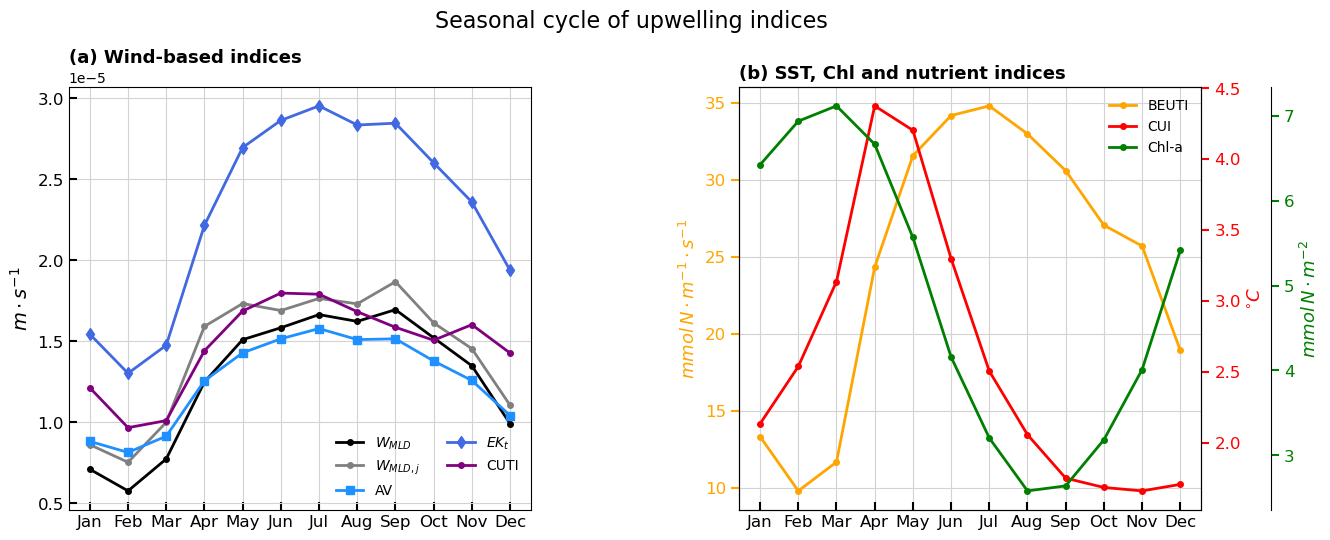

In [20]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

d = (1/12) * 10 * 111 * 1000

# ============================================================
# Seasonal cycles
# ============================================================
wmlds   = seasonality(wmld.WMLD).mean(dim=('lat', 'lon'))
Croco_j = seasonality(CROCO_j).mean(dim=('lon', 'lat_band'))
AVs     = seasonality(AV).mean(dim=('lat', 'lon'))
Ek_ts   = seasonality(Ek_t).mean(dim='lat')
CUTIs   = seasonality(CUTI).mean(dim=('lat_band', 'lon')) / d
UGEOs   = seasonality(UGEO).mean(dim=('lat_band', 'lon')) / d

BEUTIs  = seasonality(BEUTI).mean(dim=('lat_band', 'lon'))
CUIs    = seasonality(CUI.CUI_cc).mean(dim='lat')
CHLs    = seasonality(CHL.chla).mean(dim=('lat', 'lon'))

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']


def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)


# ============================================================
# Figure with two panels
# ============================================================
fig, (axL, axR_host) = plt.subplots(1, 2, figsize=(15, 5.5))

# ------------------------------------------------------------
# LEFT PANEL — wind-based indices (all share m/s)
# ------------------------------------------------------------
axL.plot(wmlds.month,   wmlds,   color='black',      lw=2, marker='o', ms=4, label='$W_{MLD}$')
axL.plot(Croco_j.month, Croco_j, color='gray',       lw=2, marker='o', ms=4, label='$W_{MLD,j}$')
axL.plot(AVs.month,     AVs,     color='dodgerblue', lw=2, marker='s', ms=6, label='AV')
axL.plot(Ek_ts.month,   Ek_ts,   color='royalblue',  lw=2, marker='d', ms=6, label='$EK_t$')
axL.plot(CUTIs.month,   CUTIs,   color='purple',     lw=2, marker='o', ms=4, label='CUTI')
# axL.plot(UGEOs.month,   UGEOs,   color='teal',       lw=2, marker='^', ms=5, label='$U_{GEO}$')

axL.set_ylabel('$m \\cdot s^{-1}$', fontsize=14)
axL.set_xticks(range(1, 13))
axL.set_xticklabels(months, fontsize=12)
axL.tick_params(axis='both', labelsize=12, direction='in', size=6, width=1.5)
axL.grid(True, color='lightgrey')
axL.set_axisbelow(True)
axL.set_title('(a) Wind-based indices', fontsize=13, loc='left', fontweight='bold')
axL.legend(fontsize=10, ncol=2, frameon=False, loc='best')

# ------------------------------------------------------------
# RIGHT PANEL — BEUTI, CUI, Chl (different units → twin axes)
# ------------------------------------------------------------
par1 = axR_host.twinx()          # CUI (°C)
par2 = axR_host.twinx()          # Chl (mmol N m⁻²)

par2.spines["right"].set_position(("axes", 1.15))
make_patch_spines_invisible(par2)
par2.spines["right"].set_visible(True)

# --- BEUTI on host ---
BEUTi, = axR_host.plot(BEUTIs.month, BEUTIs,
                       color='orange', lw=2, marker='o', ms=4, label='BEUTI')

# --- CUI on par1 ---
CUi,   = par1.plot(CUIs.month,   CUIs,
                   color='red',    lw=2, marker='o', ms=4, label='CUI')

# --- Chl on par2 ---
Chli,  = par2.plot(CHLs.month,   CHLs,
                   color='green',  lw=2, marker='o', ms=4, label='Chl-a')

# Labels and colors
axR_host.set_ylabel('$mmol\\,N \\cdot m^{-1} \\cdot s^{-1}$', fontsize=13)
par1.set_ylabel('$^{\\circ}C$', fontsize=13)
par2.set_ylabel('$mmol\\,N \\cdot m^{-2}$', fontsize=13)

axR_host.yaxis.label.set_color('orange')
par1.yaxis.label.set_color('red')
par2.yaxis.label.set_color('green')

tkw = dict(size=6, width=1.5)
axR_host.tick_params(axis='y', colors='orange', labelsize=12, **tkw)
par1.tick_params(axis='y',     colors='red',    labelsize=12, **tkw)
par2.tick_params(axis='y',     colors='green',  labelsize=12, **tkw)
axR_host.tick_params(axis='x', labelsize=12, direction='in', **tkw)

axR_host.set_xticks(range(1, 13))
axR_host.set_xticklabels(months, fontsize=12)
axR_host.grid(True, color='lightgrey')
axR_host.set_axisbelow(True)
axR_host.set_title('(b) SST, Chl and nutrient indices', fontsize=13, loc='left', fontweight='bold')

# Combined legend for right panel
handles, labels = [], []
for a_ in (axR_host, par1, par2):
    h, l = a_.get_legend_handles_labels()
    handles += h
    labels  += l
axR_host.legend(handles, labels, fontsize=10, frameon=False, loc='best')

fig.suptitle('Seasonal cycle of upwelling indices', fontsize=16, y=1.02)
fig.subplots_adjust(right=0.88, wspace=0.45)

# --- Save ---
# with PdfPages('figures/Seasonal_cycle_split.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight')

plt.show()

Text(0.5, 1.0, '$UI - CROCO$')

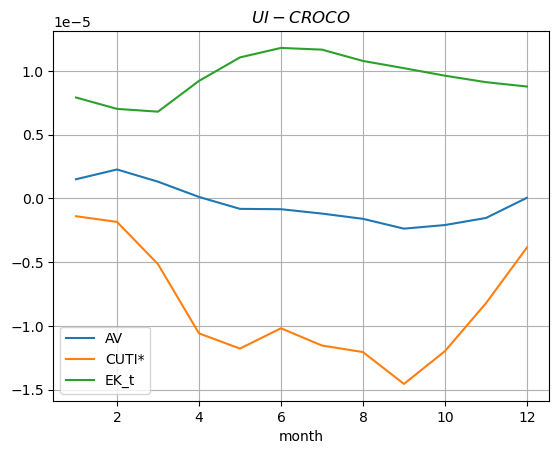

In [21]:
seasonality(AV-wmld.WMLD).mean(dim=('lon','lat')).plot(label='AV')
seasonality((CUTI/d)-CROCO_j).mean(dim=('lon','lat_band')).plot(label='CUTI*')
seasonality(Ek_t-wmld.WMLD.mean('lon')).mean('lat').plot(label='EK_t')
plt.legend()
plt.grid(True)
plt.title('$UI - CROCO$')

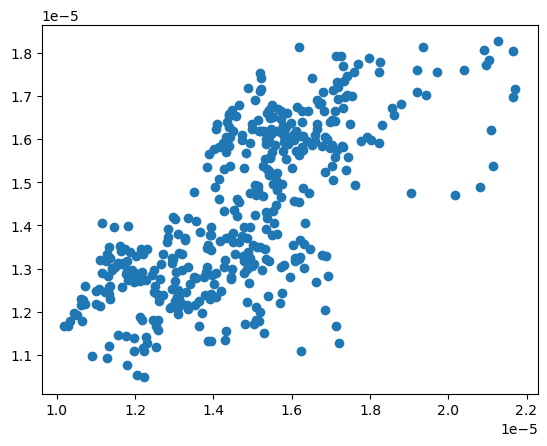

In [22]:
plt.scatter((CUTI/d).rolling(time=13).mean().mean(dim=('lon','lat_band')),CROCO_j.rolling(time=13).mean().mean(dim=('lon','lat_band')))

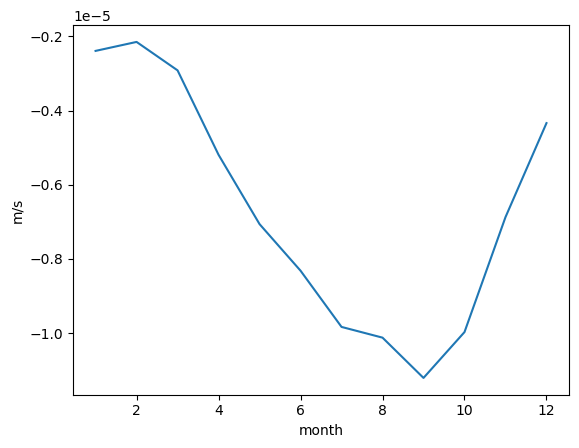

In [23]:
# seasonality(u).mean(dim=('lon','lat')).rename('m/s').plot(label='u')
seasonality(UGEO/d).mean(dim=('lon','lat_band')).rename('m/s').plot(label='ugeo')

### Taylor Plot

In [24]:

# ============================================================
# 1. Scoring function
# ============================================================
def taylor_stats(test, reference):
    """Return (std_test, std_ref, correlation, centered RMSE)."""
    test = np.asarray(test).ravel()
    reference = np.asarray(reference).ravel()

    # drop NaNs pairwise
    mask = np.isfinite(test) & np.isfinite(reference)
    test, reference = test[mask], reference[mask]

    std_test = np.std(test, ddof=1)
    std_ref  = np.std(reference, ddof=1)
    corr     = np.corrcoef(test, reference)[0, 1]
    rmse     = np.sqrt(std_test**2 + std_ref**2 - 2*std_test*std_ref*corr)
    return std_test, std_ref, corr, rmse

In [25]:
# ============================================================
# 2. Build each (index, reference) pair and score
# ============================================================
#pre-processing

# Full W_mld (3D field) for AV and Ek_t
wmld_full = seasonality(wmld.WMLD).mean(dim=('lon','lat'))

# AV vs W_mld — both have (time, lat, lon)
av_pair   = (seasonality(AV).mean(dim=('lon','lat')),  wmld_full)

# Ek_t vs W_mld averaged over lon (Ek_t only has time, lat)
bui_pair  = (seasonality(Ek_t).mean('lat'), wmld_full)

# CUTI vs CROCO_j (both on lat_band)
cuti_pair = (seasonality(CUTI / d).mean(dim=('lon','lat_band')), seasonality(CROCO_j).mean(dim=('lon','lat_band')))

pairs = {
    'AV':    av_pair,
    'EK_t':   bui_pair,
    'CUTI*': cuti_pair,
}

# Compute stats for each pair
rows = []
for name, (test, ref) in pairs.items():
    std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
    rows.append({
        'name':     name,
        'std_test': std_t,
        'std_ref':  std_r,
        'corr':     corr,
        'rmse':     rmse,
        'std_norm': std_t / std_r,   # normalized std (test / reference)
    })

stats_df = pd.DataFrame(rows).set_index('name')
print(stats_df.round(8))

       std_test   std_ref      corr      rmse  std_norm
name                                                   
AV     0.000003  0.000004  0.992287  0.000001  0.684495
EK_t   0.000006  0.000004  0.993551  0.000002  1.482060
CUTI*  0.000003  0.000004  0.890168  0.000002  0.717468


In [26]:
print(stats_df.to_string(float_format='{:.3e}'.format))

       std_test   std_ref      corr      rmse  std_norm
name                                                   
AV    2.774e-06 4.052e-06 9.923e-01 1.345e-06 6.845e-01
EK_t  6.006e-06 4.052e-06 9.936e-01 2.032e-06 1.482e+00
CUTI* 2.809e-06 3.916e-06 8.902e-01 1.908e-06 7.175e-01


In [27]:
# ============================================================
# 3. Taylor diagram plotting function (uses normalized stats)
# ============================================================
def plot_taylor(stats_df, title='Taylor diagram', savepath=None):
    """
    stats_df must have columns: std_norm, corr
    Each row becomes a point. Reference is always at (corr=1, std=1).
    """
    fig = plt.figure(figsize=(8-2, 7-2))

    # Correlation ticks
    corr_ticks  = np.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0])
    theta_ticks = np.arccos(corr_ticks)
    gl_theta = GF.FixedLocator(theta_ticks)
    tf_theta = GF.DictFormatter(dict(zip(theta_ticks, map(str, corr_ticks))))

    # Radial range (normalized std)
    smax = max(1.6, 1.2 * stats_df['std_norm'].max())

    tr = PolarAxes.PolarTransform()
    ghelper = FA.GridHelperCurveLinear(
        tr,
        extremes=(0, np.pi/2, 0, smax),
        grid_locator1=gl_theta,
        tick_formatter1=tf_theta,
    )

    ax = FA.FloatingSubplot(fig, 111, grid_helper=ghelper)
    fig.add_subplot(ax)

    ax.axis["top"].set_axis_direction("bottom")
    ax.axis["top"].toggle(ticklabels=True, label=True)
    ax.axis["top"].major_ticklabels.set_axis_direction("top")
    ax.axis["top"].label.set_axis_direction("top")
    ax.axis["top"].label.set_text("Correlation")

    ax.axis["left"].set_axis_direction("bottom")
    ax.axis["left"].label.set_text("Normalized standard deviation")

    ax.axis["right"].set_axis_direction("top")
    ax.axis["right"].toggle(ticklabels=True)
    ax.axis["right"].major_ticklabels.set_axis_direction("left")

    ax.axis["bottom"].set_visible(False)
    ax.grid(True)

    pax = ax.get_aux_axes(tr)

    # Reference point and unit-std circle
    pax.plot(0, 1.0, 'k*', markersize=14, label='Reference')
    t = np.linspace(0, np.pi/2, 100)
    pax.plot(t, np.ones_like(t), 'k--', alpha=0.5, lw=1)

    # RMSE contours (centered on reference at std=1)
    rs, ts = np.meshgrid(np.linspace(0, smax, 100), np.linspace(0, np.pi/2, 100))
    rms = np.sqrt(1.0 + rs**2 - 2*rs*np.cos(ts))
    cs = pax.contour(ts, rs, rms, levels=5, colors='gray', linestyles=':', alpha=0.6)
    pax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')

    # Plot each model
    palette = {
        'AV':    ('dodgerblue', 's'),
        'EK_t':   ('royalblue',  'd'),
        'CUTI*': ('purple',     'o'),
    }

    for name, row in stats_df.iterrows():
        color, marker = palette.get(name, ('gray', 'x'))
        theta = np.arccos(row['corr'])
        pax.plot(theta, row['std_norm'],
                 marker=marker, color=color,
                 markersize=12, linestyle='',
                 label=f"{name} (r={row['corr']:.2f})")

    pax.legend(loc='upper right', fontsize=10, numpoints=1, frameon=True)
    ax.set_title(title, fontsize=13, pad=20)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()

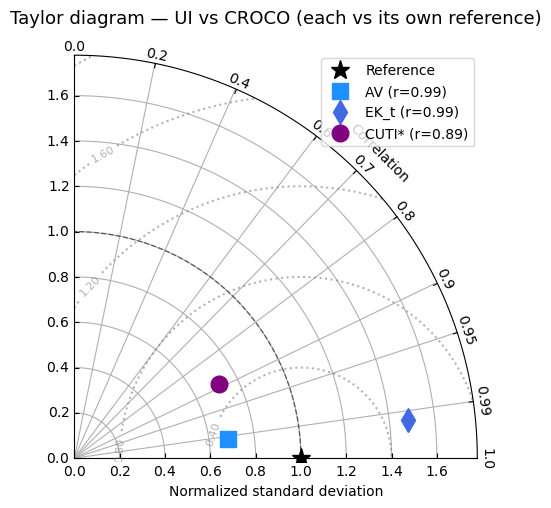

In [28]:
# ============================================================
# 4. Call it
# ============================================================
plot_taylor(
    stats_df,
    title='Taylor diagram — UI vs CROCO (each vs its own reference)',
    # savepath='figures/taylor_diagram_winds.pdf',
)

#### All UIs

In [30]:
# ============================================================
# 3. Taylor diagram plotting function (uses normalized stats)
# ============================================================
def plot_taylor_all(stats_df, title='Taylor diagram', savepath=None):
    """
    stats_df must have columns: std_norm, corr
    Each row becomes a point. Reference is always at (corr=1, std=1).
    """
    fig = plt.figure(figsize=(8-2, 7-2))

    # Correlation ticks
    corr_ticks  = np.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0])
    theta_ticks = np.arccos(corr_ticks)
    gl_theta = GF.FixedLocator(theta_ticks)
    tf_theta = GF.DictFormatter(dict(zip(theta_ticks, map(str, corr_ticks))))

    # Radial range (normalized std)
    smax = max(1.6, 1.2 * stats_df['std_norm'].max())

    tr = PolarAxes.PolarTransform()
    ghelper = FA.GridHelperCurveLinear(
        tr,
        extremes=(0, np.pi/2, 0, smax),
        grid_locator1=gl_theta,
        tick_formatter1=tf_theta,
    )

    ax = FA.FloatingSubplot(fig, 111, grid_helper=ghelper)
    fig.add_subplot(ax)

    ax.axis["top"].set_axis_direction("bottom")
    ax.axis["top"].toggle(ticklabels=True, label=True)
    ax.axis["top"].major_ticklabels.set_axis_direction("top")
    ax.axis["top"].label.set_axis_direction("top")
    ax.axis["top"].label.set_text("Correlation")

    ax.axis["left"].set_axis_direction("bottom")
    ax.axis["left"].label.set_text("Normalized standard deviation")

    ax.axis["right"].set_axis_direction("top")
    ax.axis["right"].toggle(ticklabels=True)
    ax.axis["right"].major_ticklabels.set_axis_direction("left")

    ax.axis["bottom"].set_visible(False)
    ax.grid(True)

    pax = ax.get_aux_axes(tr)

    # Reference point and unit-std circle
    pax.plot(0, 1.0, 'k*', markersize=14, label='Reference')
    t = np.linspace(0, np.pi/2, 100)
    pax.plot(t, np.ones_like(t), 'k--', alpha=0.5, lw=1)

    # RMSE contours (centered on reference at std=1)
    rs, ts = np.meshgrid(np.linspace(0, smax, 100), np.linspace(0, np.pi/2, 100))
    rms = np.sqrt(1.0 + rs**2 - 2*rs*np.cos(ts))
    cs = pax.contour(ts, rs, rms, levels=5, colors='gray', linestyles=':', alpha=0.6)
    pax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')

    # Plot each model
    palette = {
        'AV':     ('dodgerblue', 's'),
        'EK_t':   ('royalblue',  'd'),
        'CUTI*':  ('purple',     'o'),
        'BEUTI*': ('orange',     '^'),
        'CUI':    ('red',        'v'),
        'CHLs':   ('green',      'P'),
    }
    for name, row in stats_df.iterrows():
        color, marker = palette.get(name, ('gray', 'x'))
        theta = np.arccos(row['corr'])
        pax.plot(theta, row['std_norm'],
                 marker=marker, color=color,
                 markersize=12, linestyle='',
                 label=f"{name} (r={row['corr']:.2f})")

    pax.legend(loc='upper right', fontsize=10, numpoints=1, frameon=True)
    ax.set_title(title, fontsize=13, pad=20)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()

In [31]:
def zscore(x, dim='time'):
    return (x - x.mean(dim=dim)) / x.std(dim=dim)

In [32]:
# zscore(seasonality(wmld.WMLD).mean(dim=('lon','lat')),dim='month')
# zscore(seasonality(AV).mean(dim=('lon','lat')),dim='month')

wmlds  = zscore(seasonality(wmld.WMLD).mean(dim=('lat', 'lon')),dim='month')
Croco_j = zscore(seasonality(CROCO_j).mean(dim=('lon','lat_band')),dim='month')
AVs    = zscore(seasonality(AV).mean(dim=('lat', 'lon')),dim='month')
EKts   = zscore(seasonality(Ek_t).mean(dim='lat'),dim='month')
CUTIs  = zscore(seasonality(CUTI).mean(dim=('lat_band', 'lon'))/d,dim='month')
BEUTIs = zscore(seasonality(BEUTI).mean(dim=('lat_band', 'lon')),dim='month')
CUIs   = zscore(seasonality(CUI.CUI_cc).mean(dim='lat'),dim='month')
CHLs   = zscore(seasonality(CHL.chla).mean(dim=('lat', 'lon')),dim='month')

In [33]:
pairs = {
    'AV':    (AVs, wmlds),
    'EK_t':   (EKts, wmlds),
    'CUTI*': (CUTIs, Croco_j),
    'BEUTI*': (BEUTIs, Croco_j),
    'CUI': (CUIs, wmlds),
    'CHLs':(CHLs, wmlds),
}

# Compute stats for each pair
rows = []
for name, (test, ref) in pairs.items():
    std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
    rows.append({
        'name':     name,
        'std_test': std_t,
        'std_ref':  std_r,
        'corr':     corr,
        'rmse':     rmse,
        'std_norm': std_t / std_r,   # normalized std (test / reference)
    })

stats_df = pd.DataFrame(rows).set_index('name')
print(stats_df.round(3))

        std_test  std_ref   corr   rmse  std_norm
name                                             
AV         1.044    1.044  0.992  0.130       1.0
EK_t       1.044    1.044  0.994  0.119       1.0
CUTI*      1.044    1.044  0.890  0.490       1.0
BEUTI*     1.044    1.044  0.959  0.299       1.0
CUI        1.044    1.044 -0.010  1.484       1.0
CHLs       1.044    1.044 -0.854  2.011       1.0


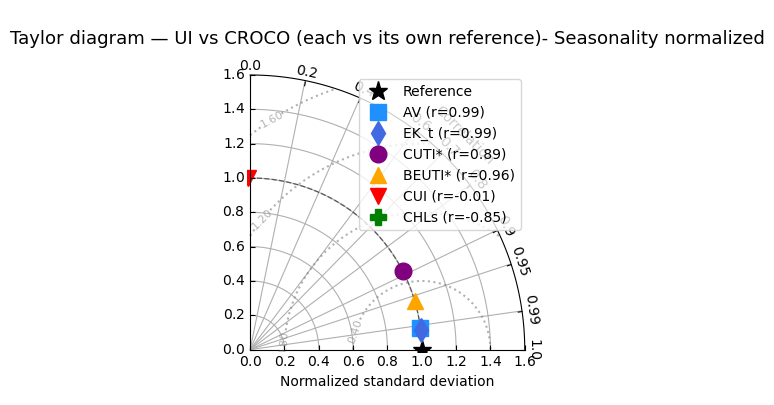

In [34]:
plot_taylor_all(
    stats_df,
    title='Taylor diagram — UI vs CROCO (each vs its own reference)- Seasonality normalized',
    # savepath='figures/taylor_diagram_winds.pdf',
)

### Taylor skill table

In [35]:
import datetime

NINO = [
    (datetime.datetime(1982, 8, 1), datetime.datetime(1983, 12, 31)),
    (datetime.datetime(1997, 4, 1), datetime.datetime(1998, 8, 30)),
]

def drop_en_events(da, en_windows=NINO, dim='time'):
    """Mask out El Niño periods from a time series."""
    mask = np.ones(da.sizes[dim], dtype=bool)
    time = da[dim].values
    for start, end in en_windows:
        start64 = np.datetime64(start)
        end64   = np.datetime64(end)
        mask &= ~((time >= start64) & (time <= end64))
    return da.isel({dim: mask})

In [36]:
def taylor_skill(std_norm, corr):
    return (4 * (1 + corr)**4) / ((std_norm + 1/std_norm)**2 * (1 + 1)**4)

def lagged_correlation(test, ref, max_lag=6):
    """
    Find the lag (in months) that maximizes |Pearson correlation|.
    Positive lag: test lags reference (test responds after ref).
    Negative lag: test leads reference.
    """
    t = np.asarray(test).ravel()
    r = np.asarray(ref).ravel()
    mask = np.isfinite(t) & np.isfinite(r)
    t, r = t[mask], r[mask]

    lags = np.arange(-max_lag, max_lag + 1)
    corrs = []
    for lag in lags:
        if lag < 0:
            # test leads: shift test forward
            tt, rr = t[:lag], r[-lag:]
        elif lag > 0:
            # test lags: shift test backward
            tt, rr = t[lag:], r[:-lag]
        else:
            tt, rr = t, r
        corrs.append(np.corrcoef(tt, rr)[0, 1])

    corrs = np.array(corrs)
    # Pick the lag with maximum absolute correlation (handles anti-correlation)
    best_idx = np.argmax(np.abs(corrs))
    return lags[best_idx], corrs[best_idx]

In [37]:
wmlds  = seasonality(drop_en_events(wmld.WMLD)).mean(dim=('lat', 'lon'))
Croco_j = seasonality(drop_en_events(CROCO_j)).mean(dim=('lon','lat_band'))
AVs    = seasonality(drop_en_events(AV)).mean(dim=('lat', 'lon'))
EKts   = seasonality(drop_en_events(Ek_t)).mean(dim='lat')
CUTIs  = seasonality(drop_en_events(CUTI)).mean(dim=('lat_band', 'lon'))/d
BEUTIs = seasonality(drop_en_events(BEUTI)).mean(dim=('lat_band', 'lon'))
CUIs   = seasonality(drop_en_events(CUI.CUI_cc)).mean(dim='lat')
CHLs   = seasonality(drop_en_events(CHL.chla)).mean(dim=('lat', 'lon'))

In [38]:
# Group 1: Dynamical indices (same units as W_mld)
dynamical_pairs = {
    'AV':    (AVs,    wmlds),
    'EK_t':  (EKts,   wmlds),
    'CUTI*': (CUTIs,  Croco_j),
}

# Group 2: Proxy indices (correlation only)
proxy_pairs = {
    'BEUTI*': (BEUTIs, Croco_j),
    'CUI':   (CUIs,   wmlds),
    'Chl':   (CHLs,   wmlds),
}

In [39]:
## for Winds
from scipy.stats import pearsonr, spearmanr

dyn_rows = []
for name, (test, ref) in dynamical_pairs.items():
    std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
    std_norm = std_t / std_r
    dyn_rows.append({
        'name': name,
        'corr': corr,
        'std_norm': std_norm,
        'rmse_norm': rmse / std_r,
        'taylor_skill': taylor_skill(std_norm, corr),
    })

dyn_df = pd.DataFrame(dyn_rows).set_index('name').sort_values('taylor_skill', ascending=False)
print("=== Dynamical indices ===")
print(dyn_df.round(3))


# --- Proxy indices with lag ---
proxy_rows = []
for name, (test, ref) in proxy_pairs.items():
    t = test.values.ravel()
    r = ref.values.ravel()
    mask = np.isfinite(t) & np.isfinite(r)
    t, r = t[mask], r[mask]

    pearson_0  = pearsonr(t, r)[0]
    spearman_0 = spearmanr(t, r)[0]
    best_lag, best_corr = lagged_correlation(t, r, max_lag=5)

    proxy_rows.append({
        'name':         name,
        'pearson':      pearson_0,
        'spearman':     spearman_0,
        'best_lag_mo':  best_lag,
        'corr_at_lag':  best_corr,
    })

proxy_df = pd.DataFrame(proxy_rows).set_index('name')
print("\n=== Proxy indices ===")
print(proxy_df.round(3))

=== Dynamical indices ===
        corr  std_norm  rmse_norm  taylor_skill
name                                           
EK_t   0.993     1.455      0.475         0.860
AV     0.991     0.671      0.348         0.840
CUTI*  0.906     0.686      0.478         0.717

=== Proxy indices ===
        pearson  spearman  best_lag_mo  corr_at_lag
name                                               
BEUTI*    0.961     0.867            0        0.961
CUI      -0.042    -0.168            3       -0.968
Chl      -0.838    -0.818           -5        0.951


### Now we exclude EN

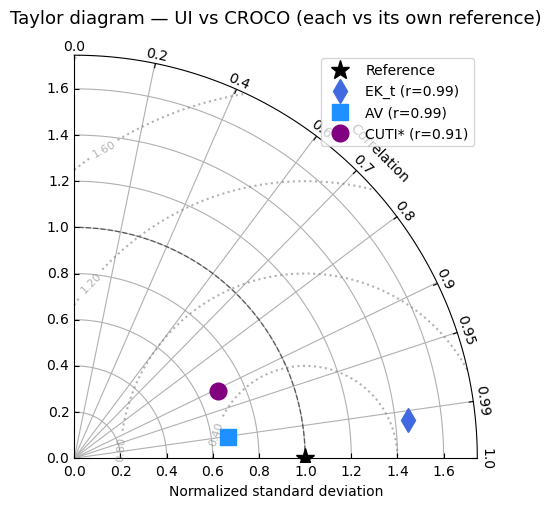

In [40]:
plot_taylor(
    dyn_df,
    title='Taylor diagram — UI vs CROCO (each vs its own reference)',
    # savepath='figures/taylor_diagram_winds.pdf',
)

* Although Ek_t and AV achieve nearly identical correlations with the seasonal cycle of W_mld (r = 0.99), the Taylor diagram (Figure X) shows that AV is closest to the reference, with a normalized standard deviation of 0.67 compared to Ek_t's 1.45. Ek_t substantially overestimates the amplitude of the seasonal cycle, while AV provides a more conservative and physically realistic estimate

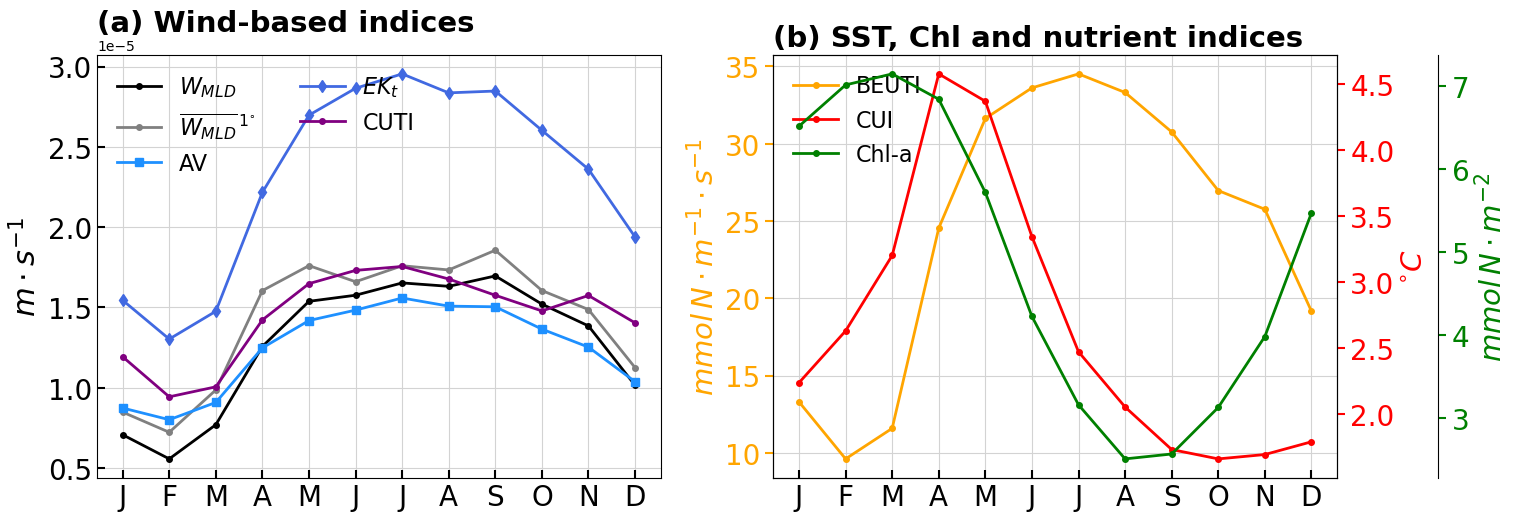

In [41]:
d = (1/12) * 10 * 111 * 1000
lsz = 8 #12 + 

# ============================================================
# Seasonal cycles
# ============================================================
wmlds  = seasonality(drop_en_events(wmld.WMLD)).mean(dim=('lat', 'lon'))
Croco_j = seasonality(drop_en_events(CROCO_j)).mean(dim=('lon','lat_band'))
AVs    = seasonality(drop_en_events(AV)).mean(dim=('lat', 'lon'))
EKts   = seasonality(drop_en_events(Ek_t)).mean(dim='lat')
CUTIs  = seasonality(drop_en_events(CUTI)).mean(dim=('lat_band', 'lon'))/d
BEUTIs = seasonality(drop_en_events(BEUTI)).mean(dim=('lat_band', 'lon'))
CUIs   = seasonality(drop_en_events(CUI.CUI_cc)).mean(dim='lat')
CHLs   = seasonality(drop_en_events(CHL.chla)).mean(dim=('lat', 'lon'))


months = ['J','F','M','A','M','J','J','A','S','O','N','D']


def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)


# ============================================================
# Figure with two panels
# ============================================================
fig, (axL, axR_host) = plt.subplots(1, 2, figsize=(16, 5.5))

# ------------------------------------------------------------
# LEFT PANEL — wind-based indices (all share m/s)
# ------------------------------------------------------------
axL.plot(wmlds.month,   wmlds,   color='black',      lw=2, marker='o', ms=4, label='$W_{MLD}$')
axL.plot(Croco_j.month, Croco_j, color='gray',       lw=2, marker='o', ms=4, label=r'$\overline{W_{MLD}}^{\,1^{\circ}}$')
axL.plot(AVs.month,     AVs,     color='dodgerblue', lw=2, marker='s', ms=6, label='AV')
axL.plot(Ek_ts.month,   Ek_ts,   color='royalblue',  lw=2, marker='d', ms=6, label='$EK_t$')
axL.plot(CUTIs.month,   CUTIs,   color='purple',     lw=2, marker='o', ms=4, label='CUTI')
# axL.plot(UGEOs.month,   UGEOs,   color='teal',       lw=2, marker='^', ms=5, label='$U_{GEO}$')

axL.set_ylabel('$m \\cdot s^{-1}$', fontsize=14+lsz)
axL.set_xticks(range(1, 13))
axL.set_xticklabels(months, fontsize=12+lsz)
axL.tick_params(axis='both', labelsize=12+lsz, direction='in', size=6, width=1.5)
axL.grid(True, color='lightgrey')
axL.set_axisbelow(True)
axL.set_title('(a) Wind-based indices', fontsize=13+lsz, loc='left', fontweight='bold')
axL.legend(fontsize=10+lsz-2, ncol=2, frameon=False, loc='best')

# ------------------------------------------------------------
# RIGHT PANEL — BEUTI, CUI, Chl (different units → twin axes)
# ------------------------------------------------------------
par1 = axR_host.twinx()          # CUI (°C)
par2 = axR_host.twinx()          # Chl (mmol N m⁻²)

par2.spines["right"].set_position(("axes", 1.18))
make_patch_spines_invisible(par2)
par2.spines["right"].set_visible(True)

# --- BEUTI on host ---
BEUTi, = axR_host.plot(BEUTIs.month, BEUTIs,
                       color='orange', lw=2, marker='o', ms=4, label='BEUTI')

# --- CUI on par1 ---
CUi,   = par1.plot(CUIs.month,   CUIs,
                   color='red',    lw=2, marker='o', ms=4, label='CUI')

# --- Chl on par2 ---
Chli,  = par2.plot(CHLs.month,   CHLs,
                   color='green',  lw=2, marker='o', ms=4, label='Chl-a')

# Labels and colors
axR_host.set_ylabel('$mmol\\,N \\cdot m^{-1} \\cdot s^{-1}$', fontsize=13+lsz)
par1.set_ylabel('$^{\\circ}C$', fontsize=13+lsz)
par2.set_ylabel('$mmol\\,N \\cdot m^{-2}$', fontsize=13+lsz)

axR_host.yaxis.label.set_color('orange')
par1.yaxis.label.set_color('red')
par2.yaxis.label.set_color('green')

tkw = dict(size=6, width=1.5)
axR_host.tick_params(axis='y', colors='orange', labelsize=12+lsz, **tkw)
par1.tick_params(axis='y',     colors='red',    labelsize=12+lsz, **tkw)
par2.tick_params(axis='y',     colors='green',  labelsize=12+lsz, **tkw)
axR_host.tick_params(axis='x', labelsize=12, direction='in', **tkw)

axR_host.set_xticks(range(1, 13))
axR_host.set_xticklabels(months, fontsize=12+lsz)
axR_host.grid(True, color='lightgrey')
axR_host.set_axisbelow(True)
axR_host.set_title('(b) SST, Chl and nutrient indices', fontsize=13+lsz, loc='left', fontweight='bold')

# Combined legend for right panel
handles, labels = [], []
for a_ in (axR_host, par1, par2):
    h, l = a_.get_legend_handles_labels()
    handles += h
    labels  += l
axR_host.legend(handles, labels, fontsize=10+lsz-2, frameon=False, loc='best')

# fig.suptitle('Seasonal cycle of upwelling indices', fontsize=16, y=1.02)
# fig.subplots_adjust(right=0.88, wspace=0.45)

#--- Save ---
# with PdfPages('figures/Seasonal_cycle_split.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight', dpi=300)

plt.show()

Text(0.5, 1.0, '$UI - CROCO$')

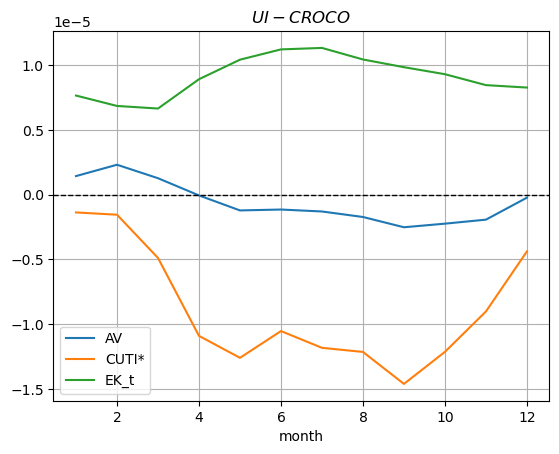

In [42]:
seasonality(drop_en_events(AV)-drop_en_events(wmld.WMLD)).mean(dim=('lon','lat')).plot(label='AV')
seasonality(drop_en_events((CUTI/d))-drop_en_events(CROCO_j)).mean(dim=('lon','lat_band')).plot(label='CUTI*')
seasonality(drop_en_events(Ek_t)-drop_en_events(wmld.WMLD).mean('lon')).mean('lat').plot(label='EK_t')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.legend()
plt.grid(True)
plt.title('$UI - CROCO$')

## Inter-annual variability

In [43]:
print(u)

<xarray.DataArray 'u' (time: 432, lat: 134, lon: 194)> Size: 90MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan

In [44]:
ageo = (u).mean(dim=('lon','lat')).data - (ugeo).mean(dim=('lon','lat_band'))
ageo

<xarray.DataArray 'u_geo' (time: 432)> Size: 3kB
array([-0.12512443, -0.0982017 , -0.05252353, -0.06894295, -0.11361465,
       -0.09453478, -0.08260719, -0.06719216, -0.09060285, -0.08498036,
       -0.09945255, -0.12024114, -0.11417966, -0.10665333, -0.07511786,
       -0.06834181, -0.0724711 , -0.05489648, -0.07738195, -0.07162773,
       -0.10145126, -0.10337942, -0.12329696, -0.12131458, -0.06244262,
        0.05583178, -0.06763567, -0.09135239, -0.09224143, -0.0815575 ,
       -0.05224226, -0.07353973, -0.08499694, -0.08517876, -0.00219297,
        0.02966654, -0.08226798, -0.12402937, -0.07006241,  0.04802339,
       -0.02669505, -0.05755442, -0.09771063, -0.09253101, -0.13078092,
       -0.10572017, -0.1215243 , -0.11514988, -0.11801412, -0.12357769,
       -0.05185576, -0.11165624, -0.12157131, -0.08264532, -0.06405038,
       -0.08110359, -0.07734685, -0.10564115, -0.09921437, -0.1299999 ,
       -0.11496209, -0.104889  , -0.1024944 , -0.11565179, -0.09619854,
       -0.07639976, -0.08093243, -0.09163231, -0.10555042, -0.0928432 ,
       -0.10252674, -0.12192185, -0.10405714, -0.08792813, -0.06612038,
       -0.10569013, -0.08858933, -0.06696282, -0.04156412, -0.04944361,
       -0.09425076, -0.08061421, -0.12322926, -0.11858646, -0.07224811,
       -0.11496718, -0.08205148, -0.08678906, -0.12030947, -0.08763746,
       -0.07427129, -0.07428227, -0.10972698, -0.11510562, -0.12405238,
       -0.12826642, -0.13260912, -0.11464214, -0.1250409 , -0.13209836,
...
       -0.10572661, -0.07814357, -0.0321466 , -0.07892383, -0.11873356,
       -0.11767623, -0.08821141, -0.05548119, -0.06590883, -0.10649634,
       -0.09887411, -0.11554294, -0.12957339, -0.11609718, -0.00293244,
       -0.02957037, -0.12805725, -0.13745355, -0.09906569, -0.06287043,
       -0.06229492, -0.12100828, -0.09910593, -0.11593168, -0.12802263,
       -0.08093449, -0.11058489, -0.143614  , -0.12591148, -0.1182716 ,
       -0.09403286, -0.09042591, -0.09222026, -0.11357747, -0.10387674,
       -0.10977652, -0.11331174, -0.09582353, -0.07393234, -0.09954116,
       -0.10876481, -0.0868621 , -0.08985016, -0.08578614, -0.0977501 ,
       -0.09105924, -0.10126112, -0.13099139, -0.12305917, -0.12719934,
       -0.06700601, -0.06901501, -0.09432801, -0.09385477, -0.09644557,
       -0.08603716, -0.09771052, -0.09133089, -0.11310891, -0.12342927,
       -0.12081972, -0.10813432, -0.05150384, -0.07552419, -0.11486187,
       -0.10713718, -0.11185149, -0.0705866 , -0.07936148, -0.09553204,
       -0.08975659, -0.08978603, -0.10105606, -0.07058275, -0.08943687,
       -0.09284208, -0.11966776, -0.08818744, -0.06062177, -0.08842798,
       -0.05481223, -0.10565669, -0.09034836, -0.09484732, -0.10042529,
       -0.10996527, -0.02540514, -0.05432463, -0.11391524, -0.11527531,
       -0.05167723, -0.08085093, -0.07867098, -0.07574906, -0.09397814,
       -0.04262359, -0.08950029])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

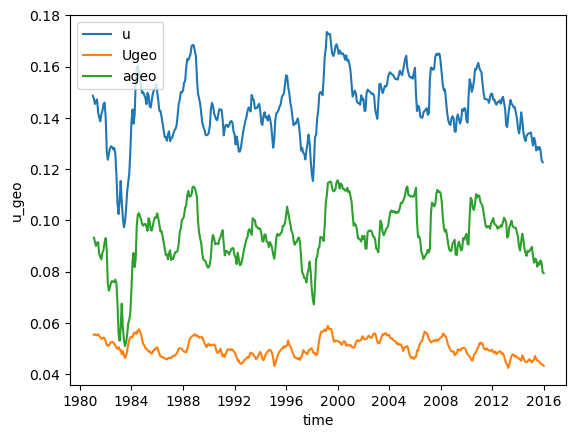

In [45]:
(u*-1).mean(dim=('lon','lat')).rolling(time=13).mean().rename('m/s').plot(label='u')
(ugeo*-1).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='Ugeo')
(ageo*-1).rolling(time=13).mean().plot(label='ageo')
plt.legend()

Text(0.5, 1.0, 'Wind based')

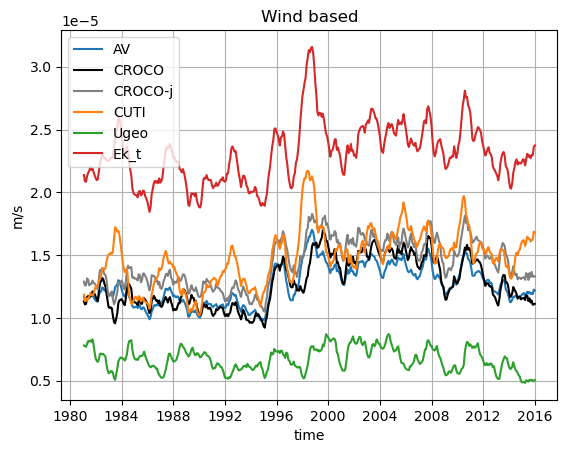

In [46]:
AV.mean(dim=('lon','lat')).rolling(time=13).mean().plot(label='AV')
wmld.WMLD.mean(dim=('lon','lat')).rolling(time=13).mean().plot(label='CROCO',color='Black')
CROCO_j.mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='CROCO-j',color='gray')

(CUTI/d).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='CUTI')
(UGEO/d*-1).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='Ugeo')

Ek_t.mean('lat').rename('m/s').rolling(time=13).mean().plot(label='Ek_t')

# seasonality(Pumping).mean(dim=('lon','lat')).plot(label='$Ek_{pumping}$')

plt.legend()
plt.grid(True)
plt.title('Wind based')

In [47]:
wmlds  = zscore(wmld.WMLD.mean(dim=('lat', 'lon')),dim='time')
Croco_j = zscore(CROCO_j.mean(dim=('lon','lat_band')),dim='time')
AVs    = zscore(AV.mean(dim=('lat', 'lon')),dim='time')
EKts   = zscore(Ek_t.mean(dim='lat'),dim='time')
CUTIs  = zscore(CUTI.mean(dim=('lat_band', 'lon'))/d,dim='time')
BEUTIs = zscore(BEUTI.mean(dim=('lat_band', 'lon')),dim='time')
CUIs   = zscore(CUI.CUI_cc.mean(dim='lat'),dim='time')
CHLs   = zscore(CHL.chla.mean(dim=('lat', 'lon')),dim='time')

pairs = {
    'AV':    (AVs, wmlds),
    'EK_t':   (EKts, wmlds),
    'CUTI*': (CUTIs, Croco_j),
    'BEUTI*': (BEUTIs, Croco_j),
    'CUI': (CUIs, wmlds),
    'CHLs':(CHLs, wmlds),
}

# Compute stats for each pair
rows = []
for name, (test, ref) in pairs.items():
    std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
    rows.append({
        'name':     name,
        'std_test': std_t,
        'std_ref':  std_r,
        'corr':     corr,
        'rmse':     rmse,
        'std_norm': std_t / std_r,   # normalized std (test / reference)
    })

stats_df = pd.DataFrame(rows).set_index('name')
print(stats_df.round(3))

        std_test  std_ref   corr   rmse  std_norm
name                                             
AV         1.001    1.001  0.922  0.395       1.0
EK_t       1.001    1.001  0.900  0.447       1.0
CUTI*      1.001    1.001  0.687  0.793       1.0
BEUTI*     1.001    1.001  0.834  0.576       1.0
CUI        1.001    1.001  0.049  1.381       1.0
CHLs       1.001    1.001 -0.599  1.790       1.0


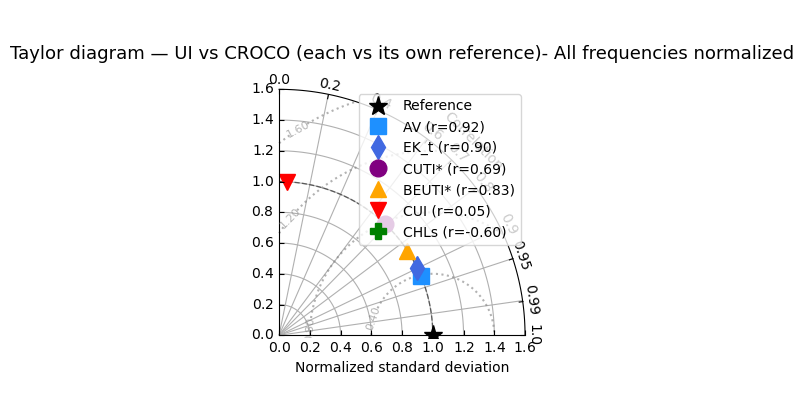

In [48]:
plot_taylor_all(
    stats_df,
    title='Taylor diagram — UI vs CROCO (each vs its own reference)- All frequencies normalized',
    # savepath='figures/taylor_diagram_winds.pdf',
)

        std_test  std_ref   corr   rmse  std_norm
name                                             
AV         1.001    1.001  0.922  0.395       1.0
EK_t       1.001    1.001  0.900  0.447       1.0
CUTI*      1.001    1.001  0.687  0.793       1.0
BEUTI*     1.001    1.001  0.834  0.576       1.0
CUI        1.001    1.001  0.049  1.381       1.0
CHLs       1.001    1.001 -0.599  1.790       1.0


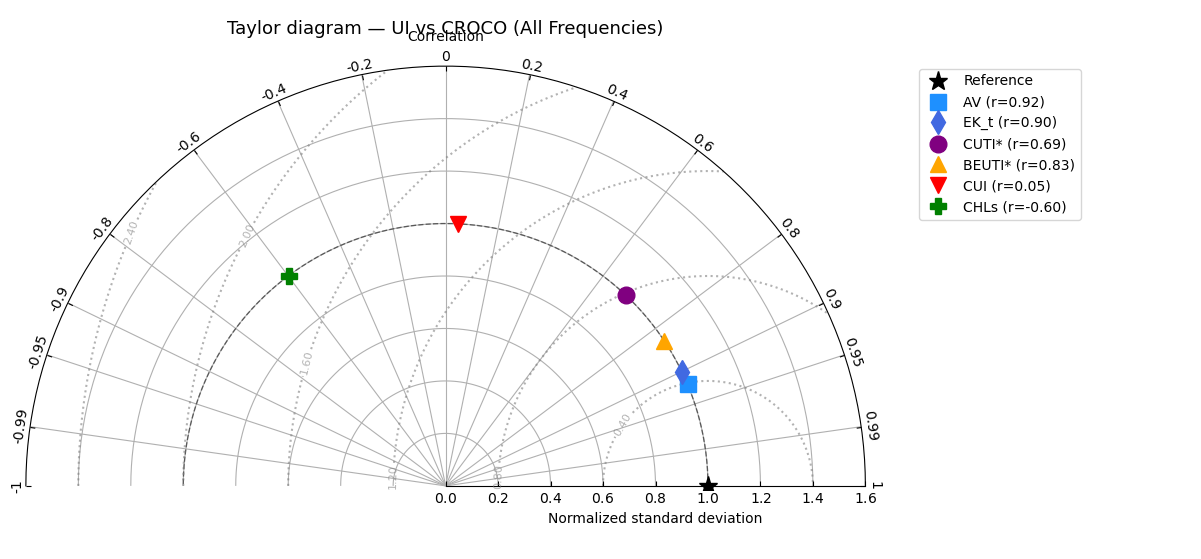

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.floating_axes as FA
import mpl_toolkits.axisartist.grid_finder as GF


# ============================================================
# Scoring function (unchanged)
# ============================================================
def taylor_stats(test, reference):
    test = np.asarray(test).ravel()
    reference = np.asarray(reference).ravel()
    mask = np.isfinite(test) & np.isfinite(reference)
    test, reference = test[mask], reference[mask]

    std_test = np.std(test, ddof=1)
    std_ref  = np.std(reference, ddof=1)
    corr     = np.corrcoef(test, reference)[0, 1]
    rmse     = np.sqrt(std_test**2 + std_ref**2 - 2*std_test*std_ref*corr)
    return std_test, std_ref, corr, rmse


# ============================================================
# Full-circle Taylor diagram plotting function
# ============================================================
def plot_taylor_full(stats_df, title='Taylor diagram', savepath=None):
    """
    Half-circle Taylor diagram covering correlations from -1 to +1.

    stats_df must have columns: std_norm, corr
    Reference sits at (corr=1, std=1).
    """
    fig = plt.figure(figsize=(11, 7))

    # Correlation ticks across [-1, 1]
    corr_ticks  = np.array([-1.0, -0.99, -0.95, -0.9, -0.8, -0.6, -0.4, -0.2,
                             0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0])
    theta_ticks = np.arccos(corr_ticks)  # theta goes from 0 (corr=1) to pi (corr=-1)

    gl_theta = GF.FixedLocator(theta_ticks)
    tf_theta = GF.DictFormatter(dict(zip(theta_ticks, [f'{c:g}' for c in corr_ticks])))

    # Radial range: normalized std
    smax = max(1.6, 1.2 * stats_df['std_norm'].max())

    tr = PolarAxes.PolarTransform()
    ghelper = FA.GridHelperCurveLinear(
        tr,
        extremes=(0, np.pi, 0, smax),   # full half-circle
        grid_locator1=gl_theta,
        tick_formatter1=tf_theta,
    )

    ax = FA.FloatingSubplot(fig, 111, grid_helper=ghelper)
    fig.add_subplot(ax)

    # Top axis: correlation label
    ax.axis["top"].set_axis_direction("bottom")
    ax.axis["top"].toggle(ticklabels=True, label=True)
    ax.axis["top"].major_ticklabels.set_axis_direction("top")
    ax.axis["top"].label.set_axis_direction("top")
    ax.axis["top"].label.set_text("Correlation")

    # Left axis: standard deviation
    ax.axis["left"].set_axis_direction("bottom")
    ax.axis["left"].label.set_text("Normalized standard deviation")

    # Right axis: hidden, since it's now interior
    ax.axis["right"].set_visible(False)

    # Bottom axis: standard deviation for negative side
    ax.axis["bottom"].set_visible(False)

    ax.grid(True)

    pax = ax.get_aux_axes(tr)

    # --- Reference point and unit-std circle ---
    pax.plot(0, 1.0, 'k*', markersize=14, label='Reference')
    t = np.linspace(0, np.pi, 200)
    pax.plot(t, np.ones_like(t), 'k--', alpha=0.5, lw=1)

    # --- RMSE contours centered on reference ---
    rs, ts = np.meshgrid(np.linspace(0, smax, 200), np.linspace(0, np.pi, 200))
    rms = np.sqrt(1.0 + rs**2 - 2*rs*np.cos(ts))
    cs = pax.contour(ts, rs, rms, levels=6, colors='gray', linestyles=':', alpha=0.6)
    pax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')

    # --- Plot each model ---
    palette = {
        'AV':     ('dodgerblue', 's'),
        'EK_t':   ('royalblue',  'd'),
        'CUTI*':  ('purple',     'o'),
        'BEUTI*': ('orange',     '^'),
        'CUI':    ('red',        'v'),
        'CHLs':   ('green',      'P'),
    }

    for name, row in stats_df.iterrows():
        color, marker = palette.get(name, ('gray', 'x'))
        theta = np.arccos(row['corr'])
        pax.plot(theta, row['std_norm'],
                 marker=marker, color=color,
                 markersize=12, linestyle='',
                 label=f"{name} (r={row['corr']:.2f})")

    pax.legend(loc='upper right', fontsize=10, numpoints=1,
               frameon=True, bbox_to_anchor=(1.25, 1.0))
    ax.set_title(title, fontsize=13, pad=20)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()


# ============================================================
# Score and plot
# ============================================================
pairs = {
    'AV':     (AVs,    wmlds),
    'EK_t':   (EKts,   wmlds),
    'CUTI*':  (CUTIs,  Croco_j),
    'BEUTI*': (BEUTIs, Croco_j),
    'CUI':    (CUIs,   wmlds),
    'CHLs':   (CHLs,   wmlds),
}

rows = []
for name, (test, ref) in pairs.items():
    std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
    rows.append({
        'name':     name,
        'std_test': std_t,
        'std_ref':  std_r,
        'corr':     corr,
        'rmse':     rmse,
        'std_norm': std_t / std_r,
    })

stats_df = pd.DataFrame(rows).set_index('name')
print(stats_df.round(3))

plot_taylor_full(
    stats_df,
    title='Taylor diagram — UI vs CROCO (All Frequencies)',
    savepath='figures/taylor_diagram_full.pdf',
)

## Normal conditions

* We remove the seasonal cycle and high frequencies with a low-pass filter, and the EN were removed

In [50]:
import datetime

NINO = [
    (datetime.datetime(1982, 8, 1), datetime.datetime(1983, 12, 31)),
    (datetime.datetime(1997, 4, 1), datetime.datetime(1998, 8, 30)),
]

def drop_en_events(da, en_windows=NINO, dim='time'):
    """Mask out El Niño periods from a time series."""
    mask = np.ones(da.sizes[dim], dtype=bool)
    time = da[dim].values
    for start, end in en_windows:
        start64 = np.datetime64(start)
        end64   = np.datetime64(end)
        mask &= ~((time >= start64) & (time <= end64))
    return da.isel({dim: mask})

In [51]:
from scipy.stats import pearsonr, spearmanr

def prep_for_taylor(da, dim='time', window=13, drop_en=True):
    """Climatology removal → running mean → drop NaNs → optionally drop EN."""
    clim = da.groupby(f'{dim}.month').mean(dim=dim)
    anom = da.groupby(f'{dim}.month') - clim
    smooth = anom.rolling({dim: window}, center=True).mean().dropna(dim=dim)
    if drop_en:
        smooth = drop_en_events(smooth)
    return smooth

def taylor_skill(std_norm, corr):
    return (4 * (1 + corr)**4) / ((std_norm + 1/std_norm)**2 * (1 + 1)**4)

def lagged_correlation(test, ref, max_lag=6):
    """
    Find the lag (in months) that maximizes |Pearson correlation|.
    Positive lag: test lags reference (test responds after ref).
    Negative lag: test leads reference.
    """
    t = np.asarray(test).ravel()
    r = np.asarray(ref).ravel()
    mask = np.isfinite(t) & np.isfinite(r)
    t, r = t[mask], r[mask]

    lags = np.arange(-max_lag, max_lag + 1)
    corrs = []
    for lag in lags:
        if lag < 0:
            # test leads: shift test forward
            tt, rr = t[:lag], r[-lag:]
        elif lag > 0:
            # test lags: shift test backward
            tt, rr = t[lag:], r[:-lag]
        else:
            tt, rr = t, r
        corrs.append(np.corrcoef(tt, rr)[0, 1])

    corrs = np.array(corrs)
    # Pick the lag with maximum absolute correlation (handles anti-correlation)
    best_idx = np.argmax(np.abs(corrs))
    return lags[best_idx], corrs[best_idx]

In [52]:

# Prepare all series
wmld_ts   = prep_for_taylor(wmld.WMLD.mean(dim=('lat','lon')))
CROCO_j_ts = prep_for_taylor(CROCO_j.mean(dim=('lon','lat_band')))

AV_ts   = prep_for_taylor(AV.mean(dim=('lat','lon')))
Ekt_ts  = prep_for_taylor(Ek_t.mean('lat'))
CUTI_ts = prep_for_taylor((CUTI/d).mean(dim=('lon','lat_band')))

BEUTI_ts = prep_for_taylor(BEUTI.mean(dim=('lon','lat_band')))
CUI_ts   = prep_for_taylor(CUI.CUI_cc.mean('lat'))
CHL_ts   = prep_for_taylor(CHL.chla.mean(dim=('lat','lon')))

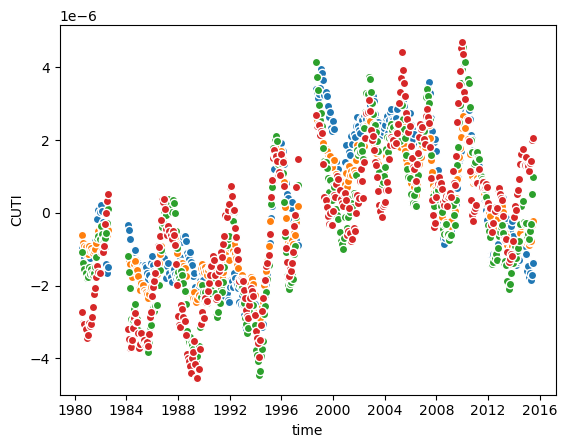

In [53]:
wmld_ts.plot.scatter()
AV_ts.plot.scatter()
Ekt_ts.plot.scatter()
CUTI_ts.plot.scatter()

In [54]:
# Group 1: Dynamical indices (same units as W_mld)
dynamical_pairs = {
    'AV':    (AV_ts,    wmld_ts),
    'Ek_t':  (Ekt_ts,   wmld_ts),
    'CUTI*': (CUTI_ts,  CROCO_j_ts),
}

# Group 2: Proxy indices (correlation only)
proxy_pairs = {
    'BEUTI': (BEUTI_ts, CROCO_j_ts),
    'CUI':   (CUI_ts,   wmld_ts),
    'Chl':   (CHL_ts,   wmld_ts.isel(time=slice(None,-1))),
}

In [55]:
## for Winds
dyn_rows = []
for name, (test, ref) in dynamical_pairs.items():
    std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
    std_norm = std_t / std_r
    dyn_rows.append({
        'name': name,
        'corr': corr,
        'std_norm': std_norm,
        'rmse_norm': rmse / std_r,
        'taylor_skill': taylor_skill(std_norm, corr),
    })

dyn_df = pd.DataFrame(dyn_rows).set_index('name').sort_values('taylor_skill', ascending=False)
print("=== Dynamical indices ===")
print(dyn_df.round(3))


# --- Proxy indices with lag ---
proxy_rows = []
for name, (test, ref) in proxy_pairs.items():
    t = test.values.ravel()
    r = ref.values.ravel()
    mask = np.isfinite(t) & np.isfinite(r)
    t, r = t[mask], r[mask]

    pearson_0  = pearsonr(t, r)[0]
    spearman_0 = spearmanr(t, r)[0]
    best_lag, best_corr = lagged_correlation(t, r, max_lag=6)

    proxy_rows.append({
        'name':         name,
        'pearson':      pearson_0,
        'spearman':     spearman_0,
        'best_lag_mo':  best_lag,
        'corr_at_lag':  best_corr,
    })

proxy_df = pd.DataFrame(proxy_rows).set_index('name')
print("\n=== Proxy indices ===")
print(proxy_df.round(3))

=== Dynamical indices ===
        corr  std_norm  rmse_norm  taylor_skill
name                                           
AV     0.944     0.773      0.372         0.836
Ek_t   0.854     1.048      0.556         0.736
CUTI*  0.743     1.095      0.756         0.572

=== Proxy indices ===
       pearson  spearman  best_lag_mo  corr_at_lag
name                                              
BEUTI    0.827     0.822            0        0.827
CUI     -0.045    -0.098           -6       -0.166
Chl     -0.419    -0.500            5       -0.489


* "Optimal lags for the dynamical indices fall within ±1 month of zero, with correlation improvements below 0.03, confirming that wind-based indices respond to the same instantaneous forcing as W_mld with no meaningful phase offset."
* The fact that the lag increases |r| from 0.42 to 0.49 at +5 months is also meaningful — it suggests there's a delayed biological response, but the delay plus sign flip means Chl is not a good proxy for physical upwelling
* CUI: r = -0.045 with Pearson, -0.098 with Spearman — essentially zero. The "best lag" at -6 months giving r = -0.166 is meaningless; that's just the edge of your search window and the correlation is still near zero. This is a null result, not a signal.
*  These results emphasize that BEUTI is the only biogeochemical proxy that tracks W_mld variability faithfully in this region, while SST- and Chl-based indices reflect distinct physical and ecological processes.


In [56]:
# ## for Winds
# dyn_rows = []
# for name, (test, ref) in dynamical_pairs.items():
#     std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
#     std_norm = std_t / std_r
#     best_lag, best_corr = lagged_correlation(test.values, ref.values, max_lag=6)
#     dyn_rows.append({
#         'name':         name,
#         'corr':         corr,
#         'std_norm':     std_norm,
#         'rmse_norm':    rmse / std_r,
#         'taylor_skill': taylor_skill(std_norm, corr),
#         'best_lag_mo':  best_lag,
#         'corr_at_lag':  best_corr,
#     })

# dyn_df = pd.DataFrame(dyn_rows).set_index('name').sort_values('taylor_skill', ascending=False)
# print("=== Dynamical indices ===")
# print(dyn_df.round(3))

## Now EN

In [57]:
def prep_for_taylor(da, dim='time', window=13, drop_en=False):
    """Climatology removal → running mean → drop NaNs → optionally drop EN."""
    clim = da.groupby(f'{dim}.month').mean(dim=dim)
    anom = da.groupby(f'{dim}.month') - clim
    smooth = anom.rolling({dim: window}, center=True).mean().dropna(dim=dim)
    if drop_en:
        smooth = drop_en_events(smooth)
    return smooth

In [58]:
# Prepare all series
wmld_ts   = prep_for_taylor(wmld.WMLD.mean(dim=('lat','lon')))
CROCO_j_ts = prep_for_taylor(CROCO_j.mean(dim=('lon','lat_band')))

AV_ts   = prep_for_taylor(AV.mean(dim=('lat','lon')))
Ekt_ts  = prep_for_taylor(Ek_t.mean('lat'))
CUTI_ts = prep_for_taylor((CUTI/d).mean(dim=('lon','lat_band')))

BEUTI_ts = prep_for_taylor(BEUTI.mean(dim=('lon','lat_band')))
CUI_ts   = prep_for_taylor(CUI.CUI_cc.mean('lat'))
CHL_ts   = prep_for_taylor(CHL.chla.mean(dim=('lat','lon')))

### Scatter plots

In [59]:
# Group 1: Dynamical indices (same units as W_mld)
dynamical_pairs = {
    'AV':    (AV_ts,    wmld_ts),
    '$Ek_t$':  (Ekt_ts,   wmld_ts),
    'CUTI*': (CUTI_ts,  CROCO_j_ts),
}

# Group 2: Proxy indices (correlation only)
proxy_pairs = {
    'BEUTI': (BEUTI_ts, CROCO_j_ts),
    'CUI':   (CUI_ts,   wmld_ts),
    'Chl':   (CHL_ts,   wmld_ts),
}

In [60]:
CHL_ts['time'] = wmld_ts.time
CHL_ts['time']

<xarray.DataArray 'time' (time: 420)> Size: 3kB
array(['1980-07-31T00:00:00.000000000', '1980-08-31T00:00:00.000000000',
       '1980-09-30T00:00:00.000000000', ..., '2015-04-30T00:00:00.000000000',
       '2015-05-31T00:00:00.000000000', '2015-06-30T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    month    (time) int64 3kB 7 8 9 10 11 12 1 2 3 4 ... 9 10 11 12 1 2 3 4 5 6
  * time     (time) datetime64[ns] 3kB 1980-07-31 1980-08-31 ... 2015-06-30

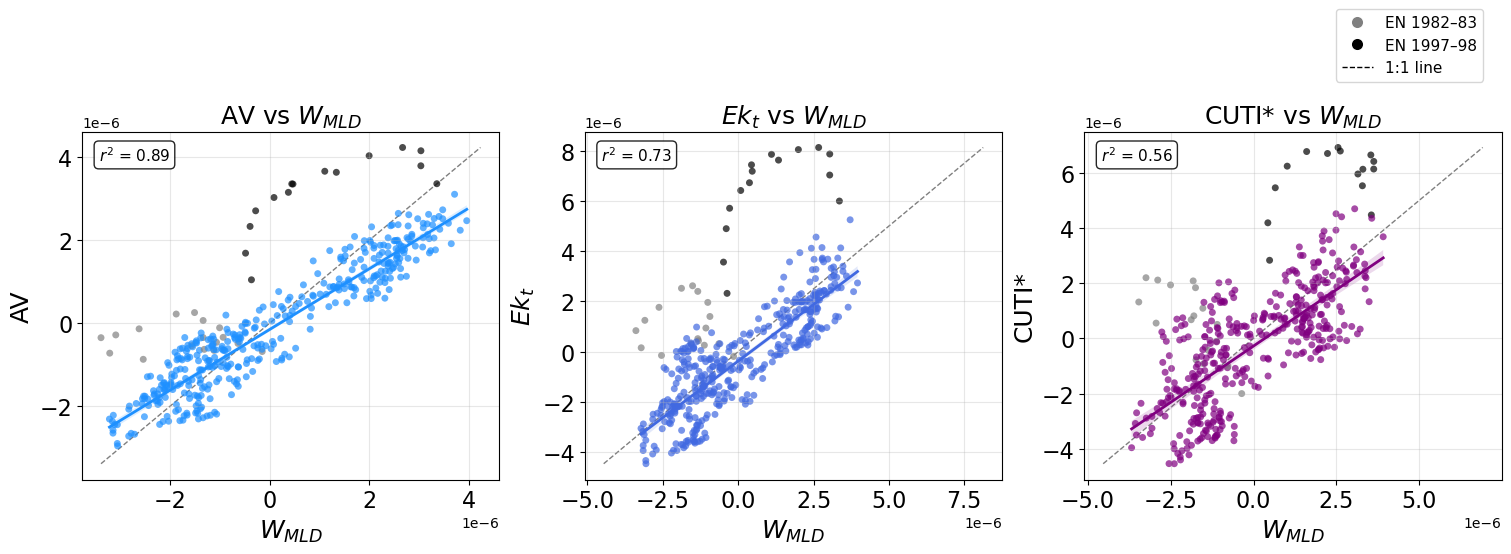

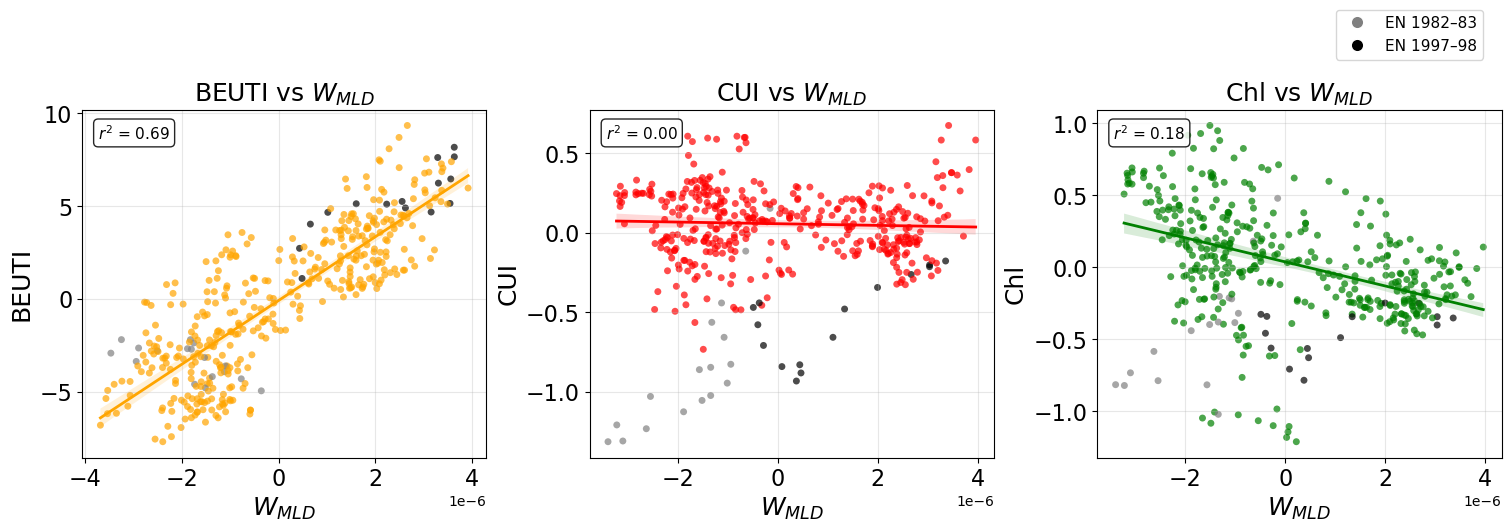

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import pearsonr

#label size
lsz = 6
# EN windows (same as used for scoring)
EN1 = (pd.Timestamp('1982-08-01'), pd.Timestamp('1983-12-31'))
EN2 = (pd.Timestamp('1997-04-01'), pd.Timestamp('1998-06-30'))

BASE_COLORS = {
    'AV':    'dodgerblue',
    '$Ek_t$':  'royalblue',
    'CUTI*': 'purple',
    'BEUTI': 'orange',
    'CUI':   'red',
    'Chl':   'green',
}


def _align_pair(test, ref):
    """Align two xarray DataArrays in time and return a pandas DataFrame."""
    t, r = xr.align(test, ref, join='inner')
    df = pd.DataFrame({
        'time':  pd.to_datetime(t.time.values),
        'test':  t.values.ravel(),
        'ref':   r.values.ravel(),
    }).dropna()
    return df


def _en_masks(time_series):
    t = pd.to_datetime(time_series)
    en1 = (t >= EN1[0]) & (t <= EN1[1])
    en2 = (t >= EN2[0]) & (t <= EN2[1])
    return en1.to_numpy(), en2.to_numpy()


def _point_colors(n, base_color, en1, en2, alpha=0.7):
    c = np.array([to_rgba(base_color, alpha)] * n, dtype=object)
    c[en1] = to_rgba('gray',  alpha)
    c[en2] = to_rgba('black', alpha)
    return c


def plot_scatter_matrix(pairs, ref_label='W_mld', ncols=3, title=None,
                        show_one_to_one=True, savepath=None):
    """
    Scatter each (index, reference) pair with EN points highlighted.
    Reference (model) goes on the x-axis, index on the y-axis.
    Regression line and r² are computed on NON-EN points only.
    """
    n = len(pairs)
    nrows = int(np.ceil(n / ncols))

    fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
                            constrained_layout=True)
    axs = np.atleast_1d(axs).flatten()

    for ax, (name, (test, ref)) in zip(axs, pairs.items()):
        df = _align_pair(test, ref)
        if df.empty:
            ax.axis('off')
            continue

        en1, en2 = _en_masks(df['time'])
        non_en = ~(en1 | en2)

        # Model (reference) on x, Index (test) on y
        x = df['ref'].to_numpy()
        y = df['test'].to_numpy()

        base_color = BASE_COLORS.get(name, 'tab:blue')
        colors = _point_colors(len(df), base_color, en1, en2, alpha=0.7)

        # Scatter all points
        ax.scatter(x, y, c=colors, edgecolors='none', s=25)

        # Regression on non-EN points only
        try:
            sns.regplot(
                x=x[non_en], y=y[non_en], ax=ax, ci=95, scatter=False,
                line_kws={'color': base_color, 'lw': 2},
            )
            r, _ = pearsonr(x[non_en], y[non_en])
            label = f"$r^2$ = {r**2:.2f}"
        except Exception:
            label = "$r^2$ n/a"

        # 1:1 reference line (only meaningful when units match)
        if show_one_to_one:
            lims = [min(x.min(), y.min()), max(x.max(), y.max())]
            ax.plot(lims, lims, 'k--', lw=1, alpha=0.5, zorder=0)

        ax.text(0.04, 0.96, label,
                transform=ax.transAxes, va='top', ha='left', fontsize=11,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

        ax.set_xlabel(ref_label, fontsize=12+lsz)
        ax.set_ylabel(name,      fontsize=12+lsz)
        ax.set_title(f'{name} vs {ref_label}', fontsize=12+lsz)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=10+lsz)

    # Hide unused subplots
    for ax in axs[n:]:
        ax.axis('off')

    # EN legend
    legend_elems = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markersize=9, label='EN 1982–83'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
               markersize=9, label='EN 1997–98'),
    ]
    if show_one_to_one:
        legend_elems.append(
            Line2D([0], [0], color='k', linestyle='--', lw=1, label='1:1 line')
        )
    fig.legend(handles=legend_elems, loc='lower right',
               bbox_to_anchor=(0.99, 1.02), frameon=True, fontsize=11)

    if title:
        fig.suptitle(title, fontsize=14, y=1.04)

    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=300)

    return fig, axs


# ============================================================
# Use it
# ============================================================
# Dynamical indices — same units → show 1:1 line
fig1, _ = plot_scatter_matrix(
    dynamical_pairs,
    ref_label='$W_{MLD}$',
    ncols=3,
    # title='Dynamical indices vs $W_{MLD}$ (interannual, EN excluded from fit)',
    show_one_to_one=True,
    # savepath='figures/scatter_dynamical.pdf',
)
plt.show()

# Proxy indices — different units → no 1:1 line
fig2, _ = plot_scatter_matrix(
    proxy_pairs,
    ref_label='$W_{MLD}$',
    ncols=3,
    # title='Proxy indices vs $W_{MLD}$ (interannual, EN excluded from fit)',
    show_one_to_one=False,
    # savepath='figures/scatter_proxy.pdf',
)
plt.show()

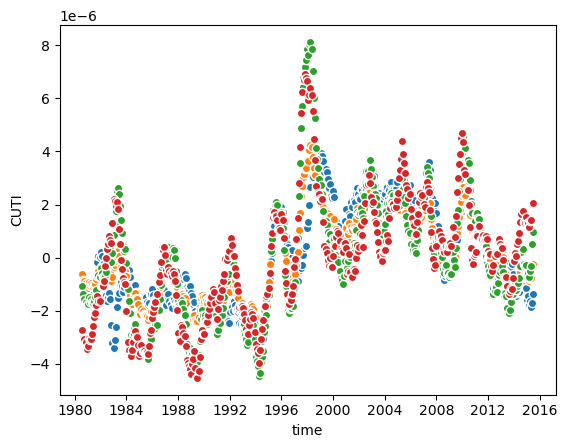

In [62]:
wmld_ts.plot.scatter()
AV_ts.plot.scatter()
Ekt_ts.plot.scatter()
CUTI_ts.plot.scatter()

## Taylor skill

In [63]:
## for Winds
dyn_rows = []
for name, (test, ref) in dynamical_pairs.items():
    std_t, std_r, corr, rmse = taylor_stats(test.values, ref.values)
    std_norm = std_t / std_r
    dyn_rows.append({
        'name': name,
        'corr': corr,
        'std_norm': std_norm,
        'rmse_norm': rmse / std_r,
        'taylor_skill': taylor_skill(std_norm, corr),
    })

dyn_df = pd.DataFrame(dyn_rows).set_index('name').sort_values('taylor_skill', ascending=False)
print("=== Dynamical indices ===")
print(dyn_df.round(3))


# --- Proxy indices with lag ---
proxy_rows = []
for name, (test, ref) in proxy_pairs.items():
    t = test.values.ravel()
    r = ref.values.ravel()
    mask = np.isfinite(t) & np.isfinite(r)
    t, r = t[mask], r[mask]

    pearson_0  = pearsonr(t, r)[0]
    spearman_0 = spearmanr(t, r)[0]
    best_lag, best_corr = lagged_correlation(t, r, max_lag=6)

    proxy_rows.append({
        'name':         name,
        'pearson':      pearson_0,
        'spearman':     spearman_0,
        'best_lag_mo':  best_lag,
        'corr_at_lag':  best_corr,
    })

proxy_df = pd.DataFrame(proxy_rows).set_index('name')
print("\n=== Proxy indices ===")
print(proxy_df.round(3))

=== Dynamical indices ===
         corr  std_norm  rmse_norm  taylor_skill
name                                            
AV      0.889     0.817      0.464         0.764
$Ek_t$  0.726     1.231      0.853         0.531
CUTI*   0.700     1.203      0.874         0.504

=== Proxy indices ===
       pearson  spearman  best_lag_mo  corr_at_lag
name                                              
BEUTI    0.837     0.828           -1        0.839
CUI      0.077    -0.055            2        0.089
Chl     -0.335    -0.412            5       -0.385


## Amplitude of drivers

In [166]:
SST = xr.open_dataset('SST.nc').compute()
SST= SST.where(SST.SST!=0,np.nan)
SST

<xarray.Dataset> Size: 564MB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    SST      (time, lat, lon) float32 564MB 20.19 20.18 20.24 ... nan nan nan

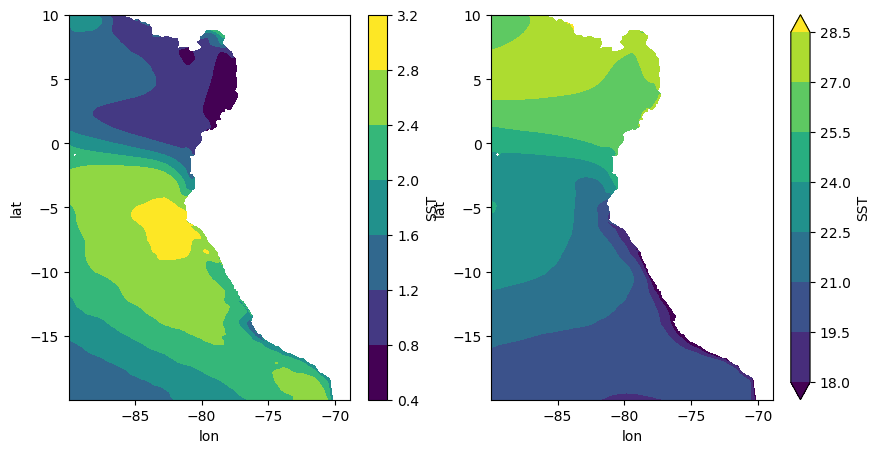

In [167]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
SST.SST.std('time').sel(lon=slice(-90,None),lat=slice(-20,None)).plot.contourf(robust=True,ax=ax[0])
SST.SST.mean('time').sel(lon=slice(-90,None),lat=slice(-20,None)).plot.contourf(robust=True,ax=ax[1])

In [168]:
mask = coastal_band_mask(SST,'SST',10).sel(lon=slice(-85,None),lat=slice(-16,-5))
SST = SST.where(mask).SST
SST

<xarray.DataArray 'SST' (time: 432, lat: 134, lon: 194)> Size: 45MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87

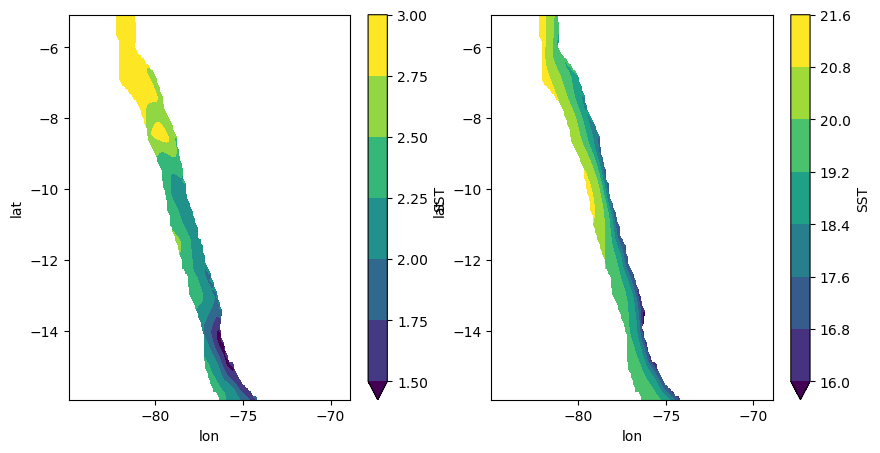

In [169]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
SST.std('time').sel(lon=slice(-90,None),lat=slice(-16,None)).plot.contourf(robust=True,ax=ax[0])
SST.mean('time').sel(lon=slice(-90,None),lat=slice(-16,None)).plot.contourf(robust=True,ax=ax[1])

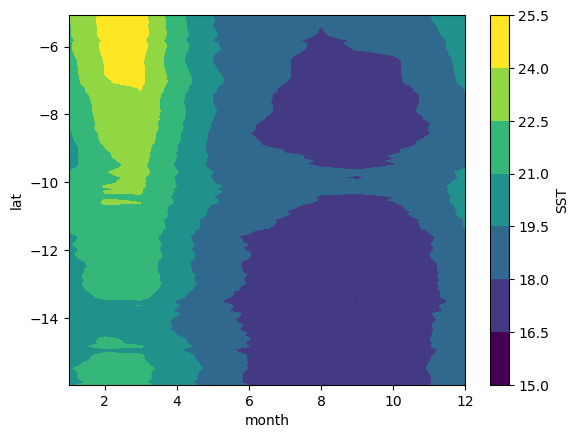

In [170]:
seasonality(SST).mean(dim='lon').plot.contourf(x='month')

In [171]:
SSTs   = prep_for_taylor(SST.mean(dim=('lat','lon')), dim='time', window=13, drop_en=False)
SSTs

<xarray.DataArray 'SST' (time: 420)> Size: 2kB
array([ 2.73465097e-01,  2.50321478e-01,  2.80462861e-01,  3.53206515e-01,
        2.82065034e-01,  2.63473809e-01,  2.67420262e-01,  2.75778264e-01,
        2.30135560e-01,  1.91901430e-01,  1.31162941e-01,  8.34969804e-02,
        7.13883936e-02,  1.88946366e-01,  3.50680590e-01,  4.53873426e-01,
        4.44563955e-01,  4.38369900e-01,  4.51168358e-01,  5.01691997e-01,
        6.01098001e-01,  7.58167148e-01,  1.01216674e+00,  1.39276361e+00,
        1.73568714e+00,  1.97357154e+00,  2.10235834e+00,  2.46660018e+00,
        2.87656879e+00,  3.28558946e+00,  3.56349230e+00,  3.71560144e+00,
        3.71137571e+00,  3.67641521e+00,  3.60495305e+00,  3.43906236e+00,
        3.15054393e+00,  2.81715584e+00,  2.58311176e+00,  2.37231660e+00,
        1.86361742e+00,  1.33880615e+00,  8.60291421e-01,  5.37676334e-01,
        3.28046381e-01,  2.49362662e-01,  1.79752499e-01,  1.10228471e-01,
       -1.69299208e-02, -1.85656339e-01, -1.93069324e-01, -3.07126582e-01,
       -3.82897764e-01, -3.43376160e-01, -3.27510566e-01, -3.59623700e-01,
       -4.26307261e-01, -4.88282591e-01, -5.39624333e-01, -5.93497932e-01,
       -6.51212275e-01, -6.20907307e-01, -5.95954478e-01, -6.62049830e-01,
       -6.03577852e-01, -5.61068773e-01, -5.52096605e-01, -5.01078427e-01,
       -4.22546983e-01, -3.46774042e-01, -3.06186259e-01, -2.84582734e-01,
       -1.79501325e-01, -1.26141623e-01, -8.24262202e-02,  6.60682097e-02,
        2.16641501e-01,  3.09442967e-01,  4.13568527e-01,  4.95451003e-01,
...
       -1.24851748e-01, -1.67068273e-01, -1.58754274e-01, -1.70177251e-01,
       -1.45349577e-01, -1.24691233e-01, -2.49766067e-01, -4.12433118e-01,
       -4.80593562e-01, -4.63969827e-01, -5.02316654e-01, -5.61722755e-01,
       -6.24014318e-01, -7.06759036e-01, -7.77288377e-01, -8.77478182e-01,
       -9.04326916e-01, -8.94278109e-01, -9.90009546e-01, -1.00291979e+00,
       -1.03343654e+00, -1.02393436e+00, -1.03346884e+00, -9.78237987e-01,
       -9.26062763e-01, -8.80840540e-01, -8.25065553e-01, -8.06904554e-01,
       -7.71262169e-01, -7.06873059e-01, -6.93956316e-01, -5.22539496e-01,
       -3.61767650e-01, -2.39938378e-01, -2.02004150e-01, -1.70440748e-01,
       -1.33666918e-01, -1.02634363e-01, -7.74021894e-02, -8.36136937e-02,
       -5.87217659e-02,  2.66105216e-02,  2.06127912e-02, -1.25190079e-01,
       -2.89792508e-01, -3.86716038e-01, -4.76193726e-01, -5.54166019e-01,
       -5.78512013e-01, -6.24842346e-01, -6.41923428e-01, -5.95964551e-01,
       -4.55457926e-01, -4.31951314e-01, -4.95525897e-01, -5.59434712e-01,
       -4.39334661e-01, -2.94202447e-01, -1.92156509e-01, -9.89882424e-02,
       -1.14575168e-02,  3.93543988e-02,  9.86789614e-02,  1.08733036e-01,
        1.88514274e-02, -2.23791432e-02,  1.66915536e-01,  3.39470595e-01,
        4.69770968e-01,  5.85239947e-01,  6.54115319e-01,  7.05409527e-01,
        7.84275293e-01,  8.56880009e-01,  9.63011801e-01,  1.05831933e+00],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-07-31 1980-08-31 ... 2015-06-30
    month    (time) int64 3kB 7 8 9 10 11 12 1 2 3 4 ... 9 10 11 12 1 2 3 4 5 6

In [172]:
SSH = xr.open_dataset('SSH.nc').compute()
SSH= SSH.where(SSH.SSH!=0,np.nan)
SSH

<xarray.Dataset> Size: 564MB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    SSH      (time, lat, lon) float32 564MB 0.212 0.212 0.2117 ... nan nan nan

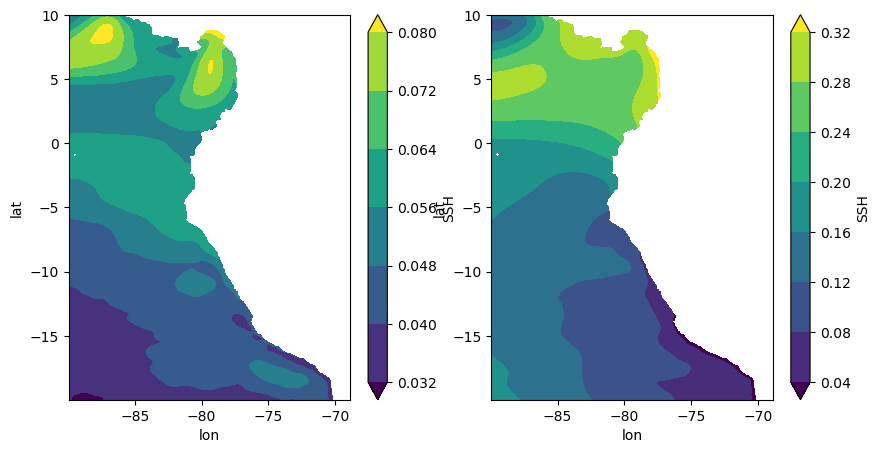

In [176]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
SSH.SSH.std('time').sel(lon=slice(-90,None),lat=slice(-20,None)).plot.contourf(robust=True,ax=ax[0])
SSH.SSH.mean('time').sel(lon=slice(-90,None),lat=slice(-20,None)).plot.contourf(robust=True,ax=ax[1])

In [177]:
SSH = SSH.where(mask).SSH
SSH

<xarray.DataArray 'SSH' (time: 432, lat: 134, lon: 194)> Size: 45MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87

In [180]:
SSHs   = prep_for_taylor(SSH.mean(dim=('lat','lon')), dim='time', window=13, drop_en=False)
SSHs

<xarray.DataArray 'SSH' (time: 420)> Size: 2kB
array([ 1.99252479e-02,  1.79255195e-02,  1.74778774e-02,  1.70321614e-02,
        1.58629268e-02,  1.56463813e-02,  1.30645502e-02,  9.52397473e-03,
        6.30433531e-03,  4.26632911e-03,  1.45323412e-03,  7.98651541e-04,
        4.31009289e-03,  1.33051658e-02,  2.21597422e-02,  2.65057050e-02,
        2.83940770e-02,  2.83001624e-02,  2.92932279e-02,  3.33387256e-02,
        4.04256582e-02,  4.70254160e-02,  5.87401427e-02,  7.46068135e-02,
        8.63113552e-02,  9.25603136e-02,  9.30717736e-02,  1.00663401e-01,
        1.13993771e-01,  1.27284318e-01,  1.34081289e-01,  1.36036023e-01,
        1.32889301e-01,  1.28222898e-01,  1.23911843e-01,  1.12811275e-01,
        9.66577679e-02,  8.37986842e-02,  7.21099749e-02,  6.23868667e-02,
        4.57469374e-02,  2.62988470e-02,  9.01750568e-03, -1.21099222e-03,
       -7.83214811e-03, -1.13931028e-02, -1.36280432e-02, -1.84600186e-02,
       -2.23218240e-02, -2.65084747e-02, -2.97132116e-02, -3.36070955e-02,
       -3.73656116e-02, -3.73671912e-02, -3.61890346e-02, -3.81233916e-02,
       -4.19552997e-02, -4.43439260e-02, -4.64650653e-02, -5.08894026e-02,
       -5.18424250e-02, -5.06805107e-02, -4.86398041e-02, -4.75057364e-02,
       -4.27962430e-02, -3.71294022e-02, -3.32346149e-02, -2.89284922e-02,
       -2.40735654e-02, -1.88779626e-02, -1.68856345e-02, -1.44871157e-02,
       -8.63120612e-03, -6.66352315e-03, -1.73946877e-03,  2.62699462e-03,
        5.89254638e-03,  6.42846152e-03,  8.62581283e-03,  9.01433825e-03,
...
        4.96976217e-03,  4.27419180e-03,  4.66519920e-03,  4.76174848e-03,
        6.67087873e-03,  9.94696654e-03,  9.53012612e-03,  7.83885084e-03,
        6.08958304e-03,  3.32817342e-03, -1.52734155e-03, -4.39967914e-03,
       -7.72132259e-03, -1.09273512e-02, -1.27343619e-02, -1.50094405e-02,
       -1.75067522e-02, -1.87679660e-02, -2.27009207e-02, -2.09206101e-02,
       -1.84245110e-02, -1.53979389e-02, -1.18776448e-02, -8.83227307e-03,
       -8.31668545e-03, -8.07041209e-03, -8.66883248e-03, -1.06643634e-02,
       -1.09759755e-02, -1.15371970e-02, -1.28176240e-02, -9.33276117e-03,
       -8.11945181e-03, -7.57920370e-03, -7.12768082e-03, -7.44595518e-03,
       -5.47977211e-03, -2.32356018e-03, -2.38547975e-04,  1.32896029e-03,
        2.63238372e-03,  4.73640952e-03,  7.84213655e-03,  8.62242281e-03,
        5.96557651e-03,  1.90056581e-03, -2.91456119e-03, -7.16357771e-03,
       -8.37519579e-03, -1.05009014e-02, -1.22666247e-02, -1.20455949e-02,
       -9.09382384e-03, -9.08428710e-03, -1.11637479e-02, -1.26164695e-02,
       -1.03193419e-02, -7.88873062e-03, -6.29120041e-03, -5.11987507e-03,
       -5.04238810e-03, -5.18747512e-03, -3.52228992e-03, -2.68654083e-03,
       -1.82576652e-03, -1.33119419e-03,  2.97309761e-03,  7.39701418e-03,
        9.89274681e-03,  1.25913406e-02,  1.49002634e-02,  1.63545012e-02,
        2.09964160e-02,  2.74265446e-02,  3.21076736e-02,  3.59261557e-02],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-07-31 1980-08-31 ... 2015-06-30
    month    (time) int64 3kB 7 8 9 10 11 12 1 2 3 4 ... 9 10 11 12 1 2 3 4 5 6

In [185]:
MLD = xr.open_dataset('MLD.nc').compute()
MLD

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB 0.9402 0.9402 1.335 ... nan nan nan

In [188]:
MLD = MLD.where(mask).MLD
MLD

<xarray.DataArray 'MLD' (time: 432, lat: 134, lon: 194)> Size: 90MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

In [190]:
MLDs   = prep_for_taylor(MLD.mean(dim=('lat','lon')), dim='time', window=13, drop_en=False)
MLDs

<xarray.DataArray 'MLD' (time: 420)> Size: 3kB
array([-1.89143373e-03, -1.29756968e-01, -3.18106220e-01, -1.60497639e-01,
       -2.37076086e-01,  1.86111701e-01,  1.13551064e+00,  2.04058473e+00,
        2.78841116e+00,  1.94465773e+00,  1.18141382e+00,  7.03322879e-01,
        9.52572937e-01,  1.48428914e+00,  2.88278234e+00,  3.74393114e+00,
        4.09625883e+00,  4.60149116e+00,  4.64237574e+00,  4.50927928e+00,
        3.72520683e+00,  2.76504795e+00,  3.16260724e+00,  4.03281108e+00,
        5.40348430e+00,  6.01761782e+00,  5.50400430e+00,  4.60464346e+00,
        4.81944362e+00,  5.68829234e+00,  5.74797615e+00,  5.22605522e+00,
        5.16925072e+00,  5.33561007e+00,  5.54831799e+00,  5.12736175e+00,
        4.23663455e+00,  3.01658815e+00,  2.24396421e+00,  1.89877349e+00,
        1.60873270e+00,  8.80665475e-01, -2.53370238e-01,  8.88772926e-02,
        9.06313677e-01,  5.72685083e-01,  2.99439229e-01,  4.27095766e-01,
        7.17046736e-01,  7.38614876e-01,  2.17004782e-01, -1.04147958e-01,
       -9.70329794e-02, -5.95294936e-01, -8.82541699e-01, -8.75931982e-01,
       -1.55296170e+00, -2.75187744e+00, -3.22364694e+00, -3.36826881e+00,
       -3.60937952e+00, -3.83471956e+00, -3.54157660e+00, -2.86298695e+00,
       -2.59015415e+00, -2.15918509e+00, -1.40601560e+00, -1.05009741e+00,
       -8.91428421e-01, -9.90261572e-01, -6.00590529e-01, -8.98550905e-01,
       -5.88146162e-01, -3.27647502e-01,  1.75927973e-02, -1.50325755e-01,
       -9.65534731e-02, -2.09066115e-01, -1.20971536e+00, -2.31343235e+00,
...
       -2.80780068e+00, -3.04809976e+00, -2.96974288e+00, -2.96359203e+00,
       -2.09551487e+00, -1.83653663e+00, -2.55478431e+00, -2.16266720e+00,
       -1.25414260e+00, -7.21766223e-01, -2.19887460e-01, -1.17325798e-01,
        3.34434696e-01,  9.75742588e-01,  2.16719149e+00,  2.47801545e+00,
        2.90603377e+00,  2.93168167e+00,  2.88135329e+00,  3.13322887e+00,
        2.69385782e+00,  1.87356032e+00,  1.65130460e+00,  1.36625254e+00,
        1.50224980e+00,  1.29901510e+00,  1.15241031e+00,  6.81817838e-01,
        3.15657555e-01,  2.98489555e-01, -4.80640456e-01, -9.09836578e-01,
       -1.22634592e+00, -1.46717550e+00, -1.43018056e+00, -1.87605178e+00,
       -2.10878611e+00, -2.92866938e+00, -3.09755135e+00, -3.38086223e+00,
       -4.28925311e+00, -4.73328099e+00, -4.90770339e+00, -4.65426463e+00,
       -4.55113980e+00, -4.48053635e+00, -3.96634155e+00, -3.31780299e+00,
       -3.06045857e+00, -2.69248804e+00, -2.08360474e+00, -1.80174367e+00,
       -2.28274903e+00, -1.55337096e+00, -1.20467499e+00, -1.53993967e+00,
       -1.71039068e+00, -1.30774915e+00, -1.01683039e+00, -9.52531087e-01,
       -1.58738002e+00, -1.62819965e+00, -1.31171034e+00, -1.58614383e+00,
       -1.48637471e+00, -1.47419955e+00, -1.84895949e+00, -1.44696286e+00,
       -9.00596459e-01, -7.29781004e-01, -1.10326979e+00, -1.14781677e+00,
       -1.47360406e+00, -1.83055773e+00, -1.28095136e+00, -1.50466698e+00,
       -1.71056935e+00, -1.55846390e+00, -1.09242019e-01,  1.09175398e+00])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-07-31 1980-08-31 ... 2015-06-30
    month    (time) int64 3kB 7 8 9 10 11 12 1 2 3 4 ... 9 10 11 12 1 2 3 4 5 6

In [256]:
u = xr.open_dataset('UV_velocities.nc').compute().transpose('time','lat','lon')
u = u.where(u!=0,np.nan)
mask_edge = coastal_band_mask(u,'u',5).sel(lon=slice(-85,None),lat=slice(-16,-5))
u = u.where(mask_edge).u
# u

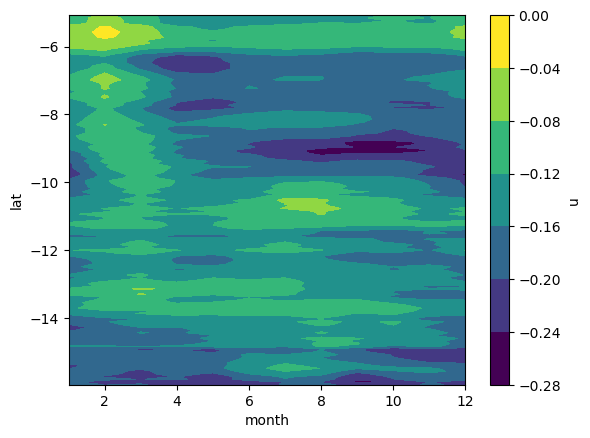

In [257]:
seasonality(u).mean('lon').plot.contourf(x='month')

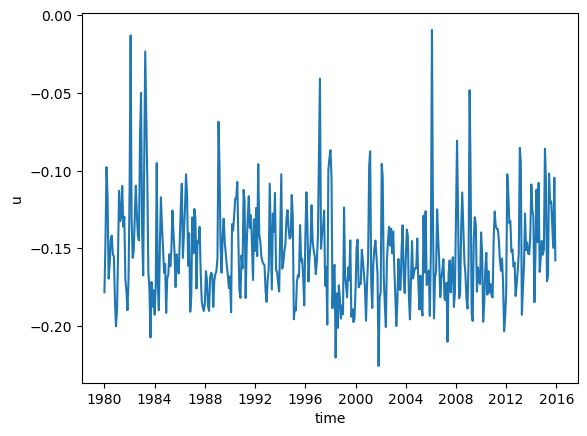

In [258]:
u.mean(dim=('lon','lat')).plot()

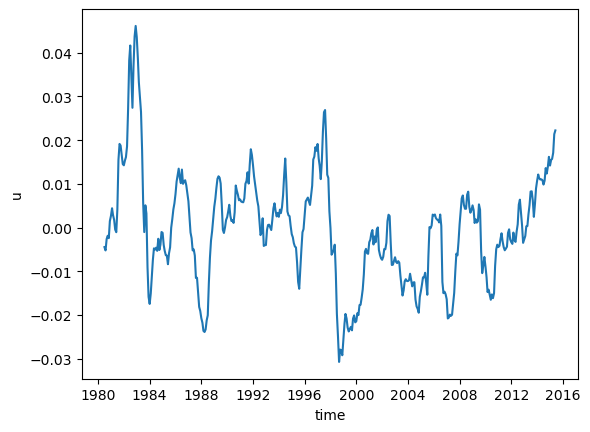

In [255]:
Us =prep_for_taylor(u.mean(dim=('lat','lon')), dim='time', window=13, drop_en=False)
Us.plot()
# Us

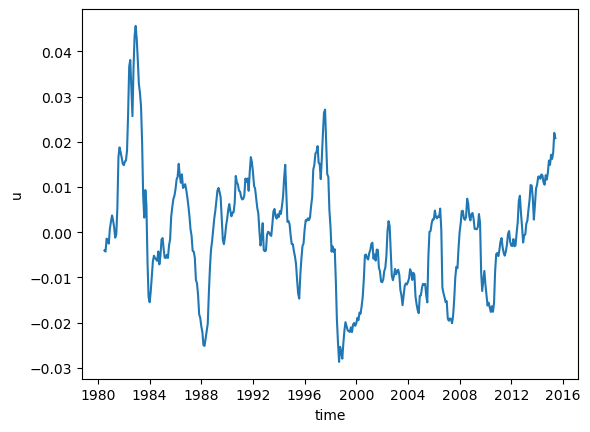

In [247]:
# SSTs.plot()
# MLDs.plot()
# SSHs.plot()
Us.plot()